# Artifact Rejection — CalmSync Artifact Dataset
## Eye Blinks, Head Nodding & Jaw Clenching
---

This notebook applies multiple artifact removal techniques to **real CalmSync EEG recordings** containing three distinct artifact types:

| Artifact | Source | EEG Signature |
|----------|--------|----------------|
| **Eye Blinks** | Ocular muscles | Large, slow deflections (~0.5–2 Hz) concentrated at frontal electrodes |
| **Head Nodding** | Body movement + electrode shift | Low-frequency drift with abrupt baseline shifts |
| **Jaw Clenching** | EMG from masseter/temporalis | High-frequency broadband burst (>20 Hz) |

We apply **five decomposition methods** and compare their ability to separate artifacts from neural signal:
1. **Wavelet Transform (WT)** — soft thresholding
2. **EMD** — Empirical Mode Decomposition
3. **EEMD** — Ensemble EMD
4. **CEEMDAN** — Complete Ensemble EMD with Adaptive Noise
5. **VMD** — Variational Mode Decomposition

## 1. Load & Preprocess
---
All three recordings come from the same CalmSync device (2-channel, ~240 Hz). We:
- Convert ADC values to **µV**
- Apply a **bandpass filter** (0.5–45 Hz) to remove DC drift and high-frequency noise
- Apply a **50 Hz notch filter** to remove line noise
- Extract the **Fp1** channel (channel 0)

In [12]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pywt
from scipy import signal
from scipy.signal import welch
from PyEMD import EMD, EEMD, CEEMDAN
from vmdpy import VMD

# ── Filter helper ────────────────────────────────────────────────────────────
def preprocess(x, fs, hp=0.5, lp=45.0, notch=50.0):
    """Bandpass + 50 Hz notch filter, then DC removal."""
    sos_bp = signal.butter(4, [hp, lp], btype='band', fs=fs, output='sos')
    x = signal.sosfiltfilt(sos_bp, x)
    b, a = signal.iirnotch(notch, Q=30, fs=fs)
    x = signal.filtfilt(b, a, x)
    x -= x.mean()
    return x

def load_calmsync(path):
    """Load CalmSync JSON, convert to µV, preprocess."""
    with open(path) as f:
        d = json.load(f)
    fs = d['samplingRateHz']
    raw = np.array(d['data'], dtype=float)
    # ADC → µV
    fp1 = ((raw[0] - 512) * 3.3 / 1024) / 1100 * 1e6
    fp1 = preprocess(fp1, fs)
    t = np.arange(len(fp1)) / fs
    return fp1, t, fs

# ── Load all three artifact types ────────────────────────────────────────────
base = r'../calmsync_artifactdata'

blink_sig, blink_t, fs = load_calmsync(f'{base}/eyeblinks/eeg_2026-01-14T17-07-28_2026-01-14T17-08-27.json')
nod_sig, nod_t, _      = load_calmsync(f'{base}/Headnodding/eeg_2026-01-14T17-14-40_2026-01-14T17-15-41.json')
jaw_sig, jaw_t, _      = load_calmsync(f'{base}/jawclenching/eeg_2026-01-14T17-11-51_2026-01-14T17-12-54.json')

artifacts = {
    'Eye Blinks':    (blink_sig, blink_t),
    'Head Nodding':  (nod_sig, nod_t),
    'Jaw Clenching': (jaw_sig, jaw_t),
}



print(f'Sampling rate: {fs:.1f} Hz')
for name, (sig, t) in artifacts.items():
    print(f'{name}: {len(sig)} samples, {t[-1]:.1f}s, '
          f'range: [{sig.min():.1f}, {sig.max():.1f}] µV')

Sampling rate: 239.8 Hz
Eye Blinks: 14162 samples, 59.1s, range: [-234.8, 236.3] µV
Head Nodding: 14622 samples, 61.0s, range: [-1073.1, 559.6] µV
Jaw Clenching: 15229 samples, 63.5s, range: [-660.2, 671.9] µV


## 2. Raw EEG — All Three Artifacts
---
Visual comparison of the three artifact types. Notice the distinct morphologies:
- **Eye blinks**: sharp, high-amplitude spikes
- **Head nodding**: slow baseline wandering
- **Jaw clenching**: dense high-frequency bursts

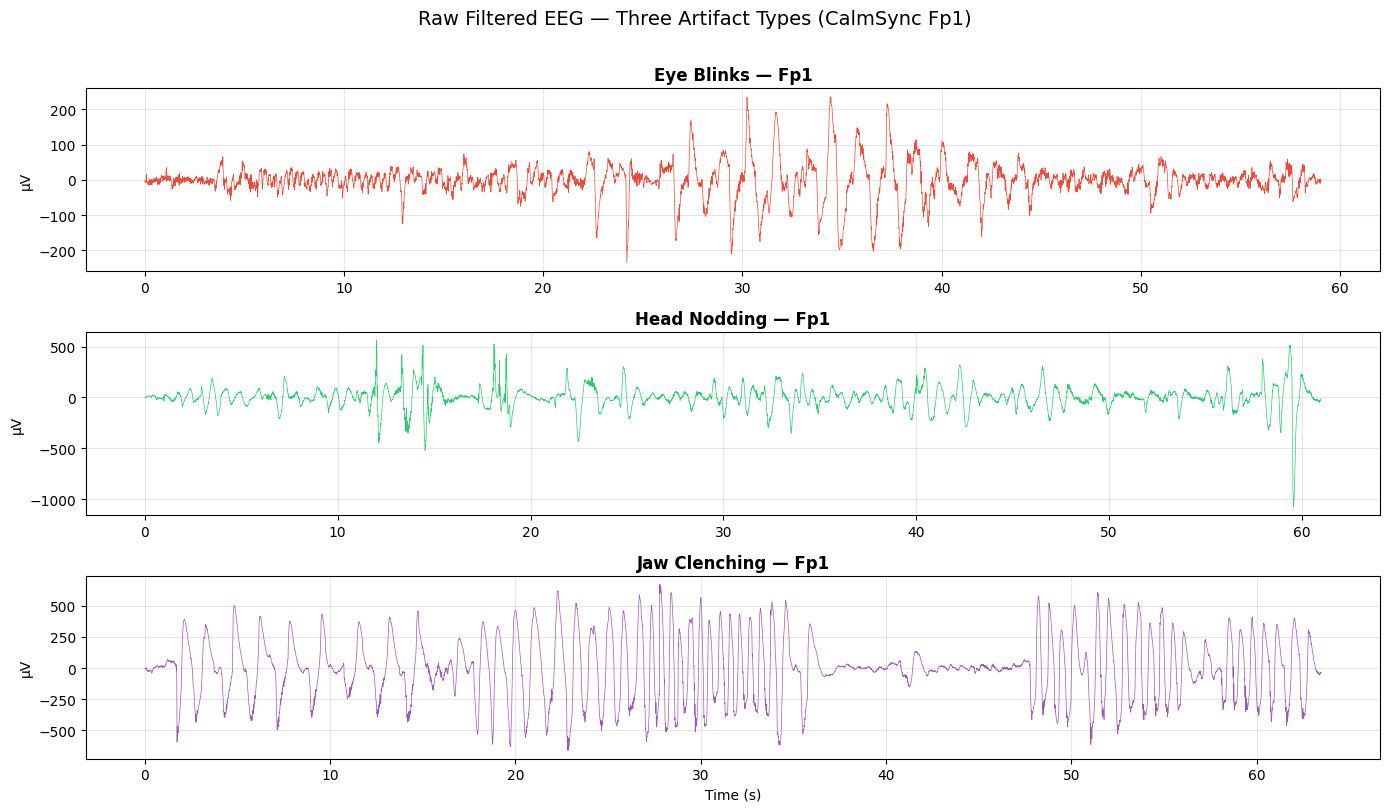

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

colors = {'Eye Blinks': '#e74c3c', 'Head Nodding': '#2ecc71', 'Jaw Clenching': '#9b59b6'}

for ax, (name, (sig, t)) in zip(axes, artifacts.items()):
    ax.plot(t, sig, color=colors[name], linewidth=0.5)
    ax.set_title(f'{name} — Fp1', fontsize=12, fontweight='bold')
    ax.set_ylabel('µV')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw Filtered EEG — Three Artifact Types (CalmSync Fp1)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Wavelet Transform (Soft Thresholding)
---
We decompose with the **db4** wavelet (5 levels), estimate noise from the finest detail coefficients using the **MAD estimator**, and apply **soft thresholding**. The denoised signal is then reconstructed.

Artifact           Method                      Energy Removed (%)   Corr w/ Original
Eye Blinks         Fixed Universal                          0.9%             0.9993
Eye Blinks         Per-Level Adaptive                       5.5%             0.9751
Eye Blinks         Level-Dep Scaling (α)                    4.9%             0.9818
Eye Blinks         BayesShrink                              0.0%             1.0000
Eye Blinks         SURE                                     0.0%             0.9999
Eye Blinks         NeighBlock                               1.1%             0.9992
Eye Blinks         Time-Adaptive                            5.5%             0.9754
-------------------------------------------------------------------------------------
Head Nodding       Fixed Universal                          0.4%             0.9998
Head Nodding       Per-Level Adaptive                       5.1%             0.9883
Head Nodding       Level-Dep Scaling (α)                    3.6%         

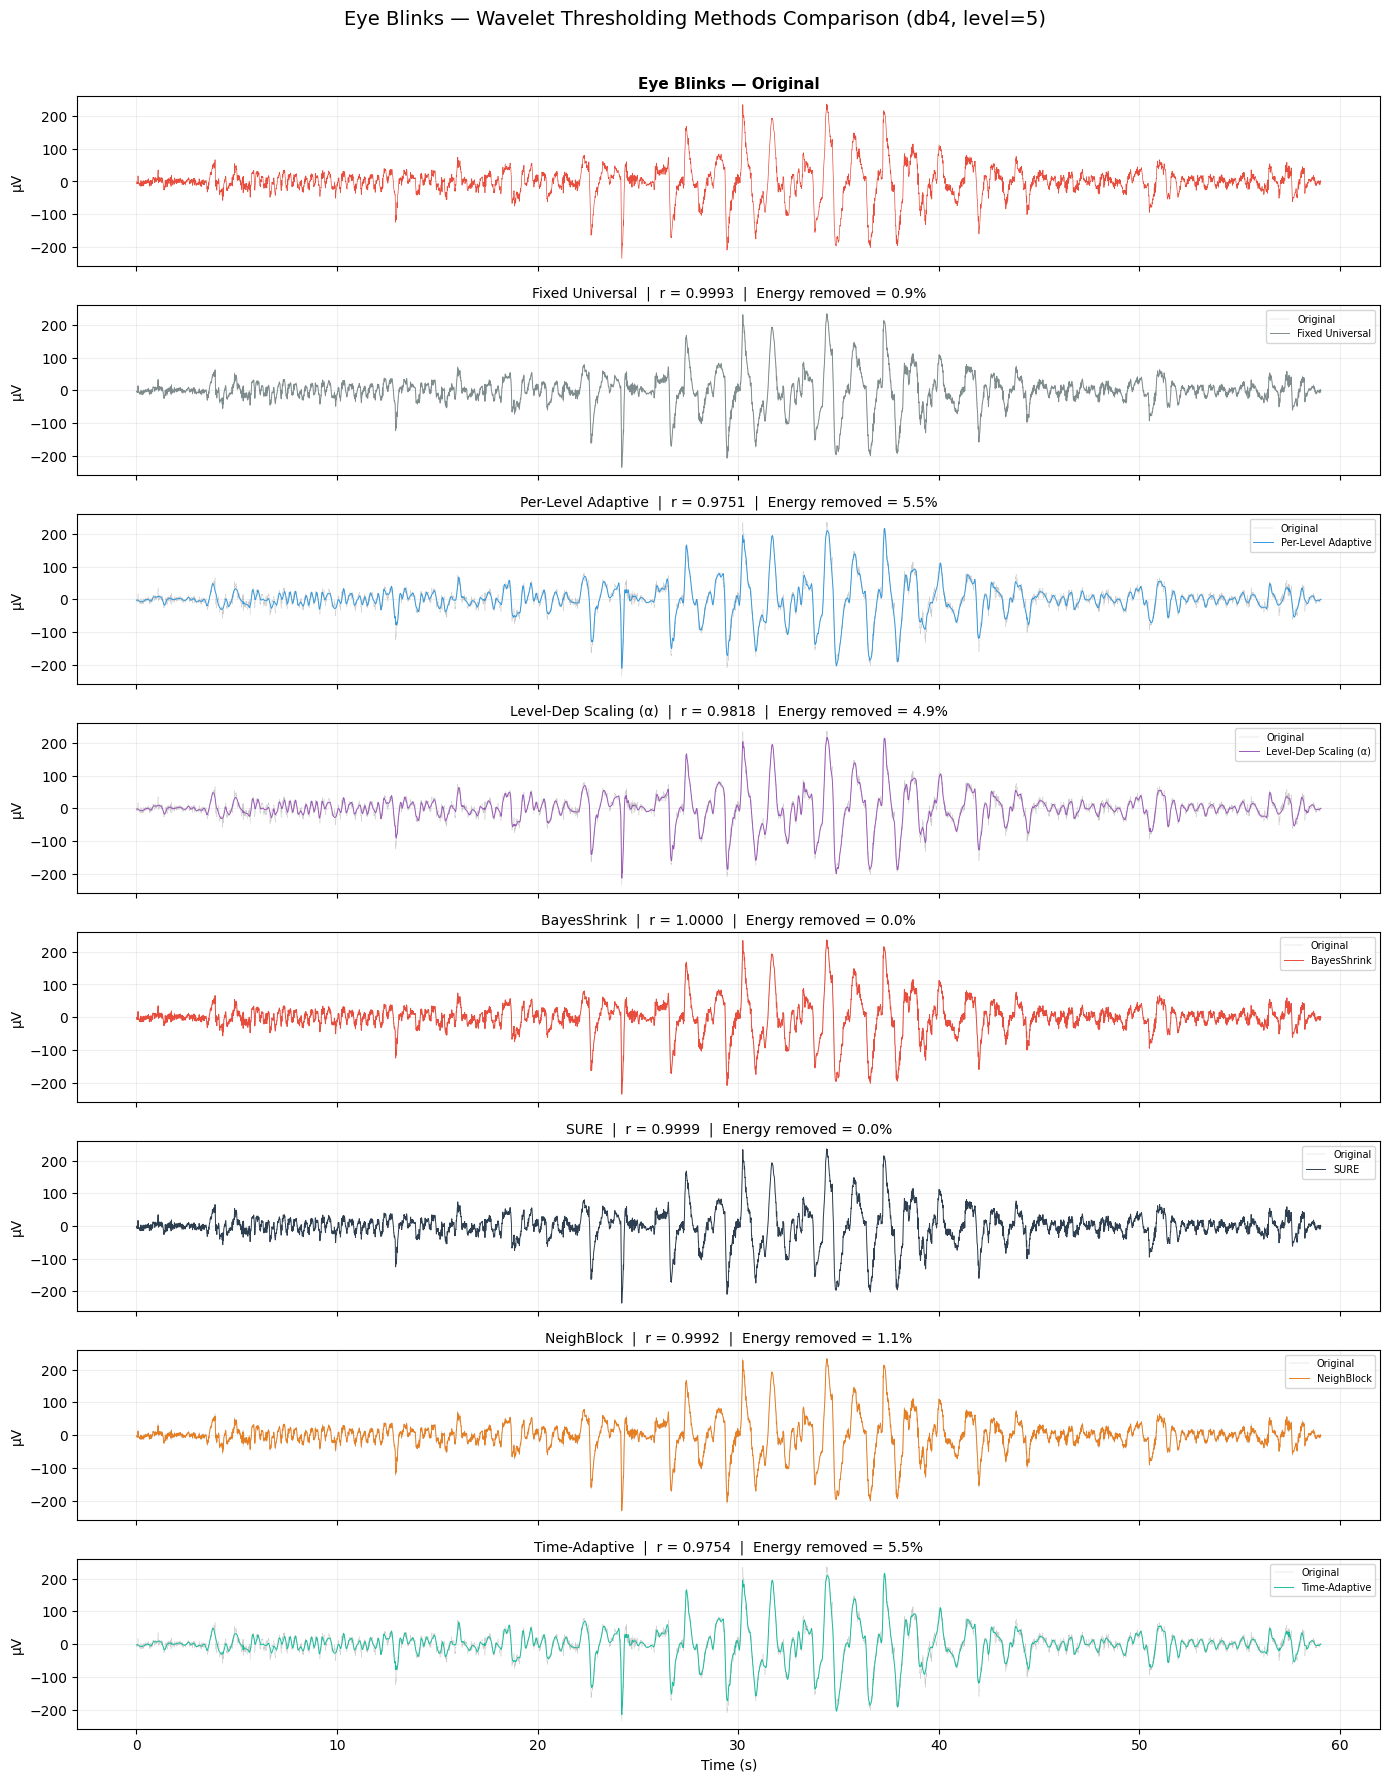

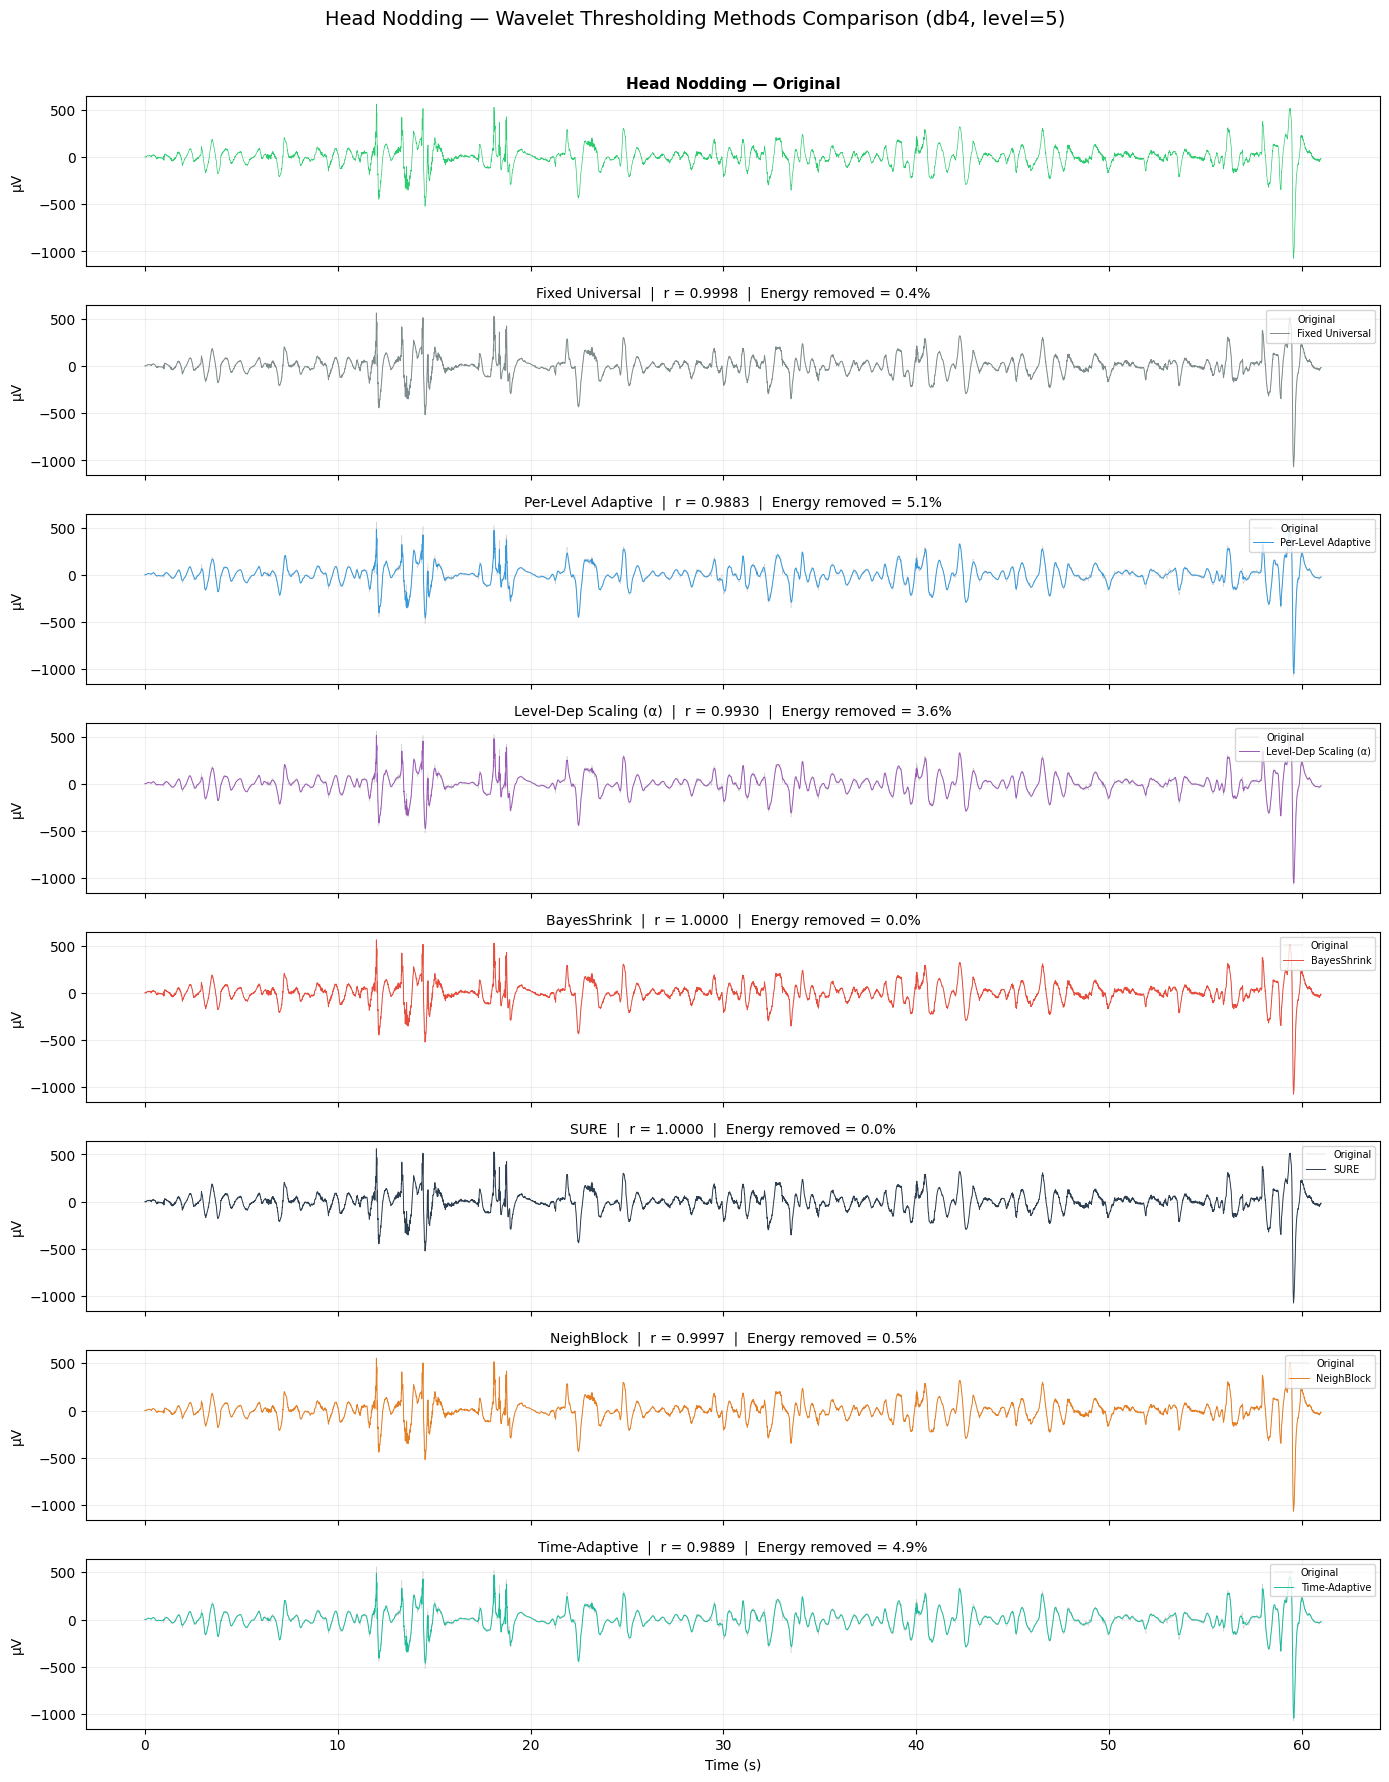

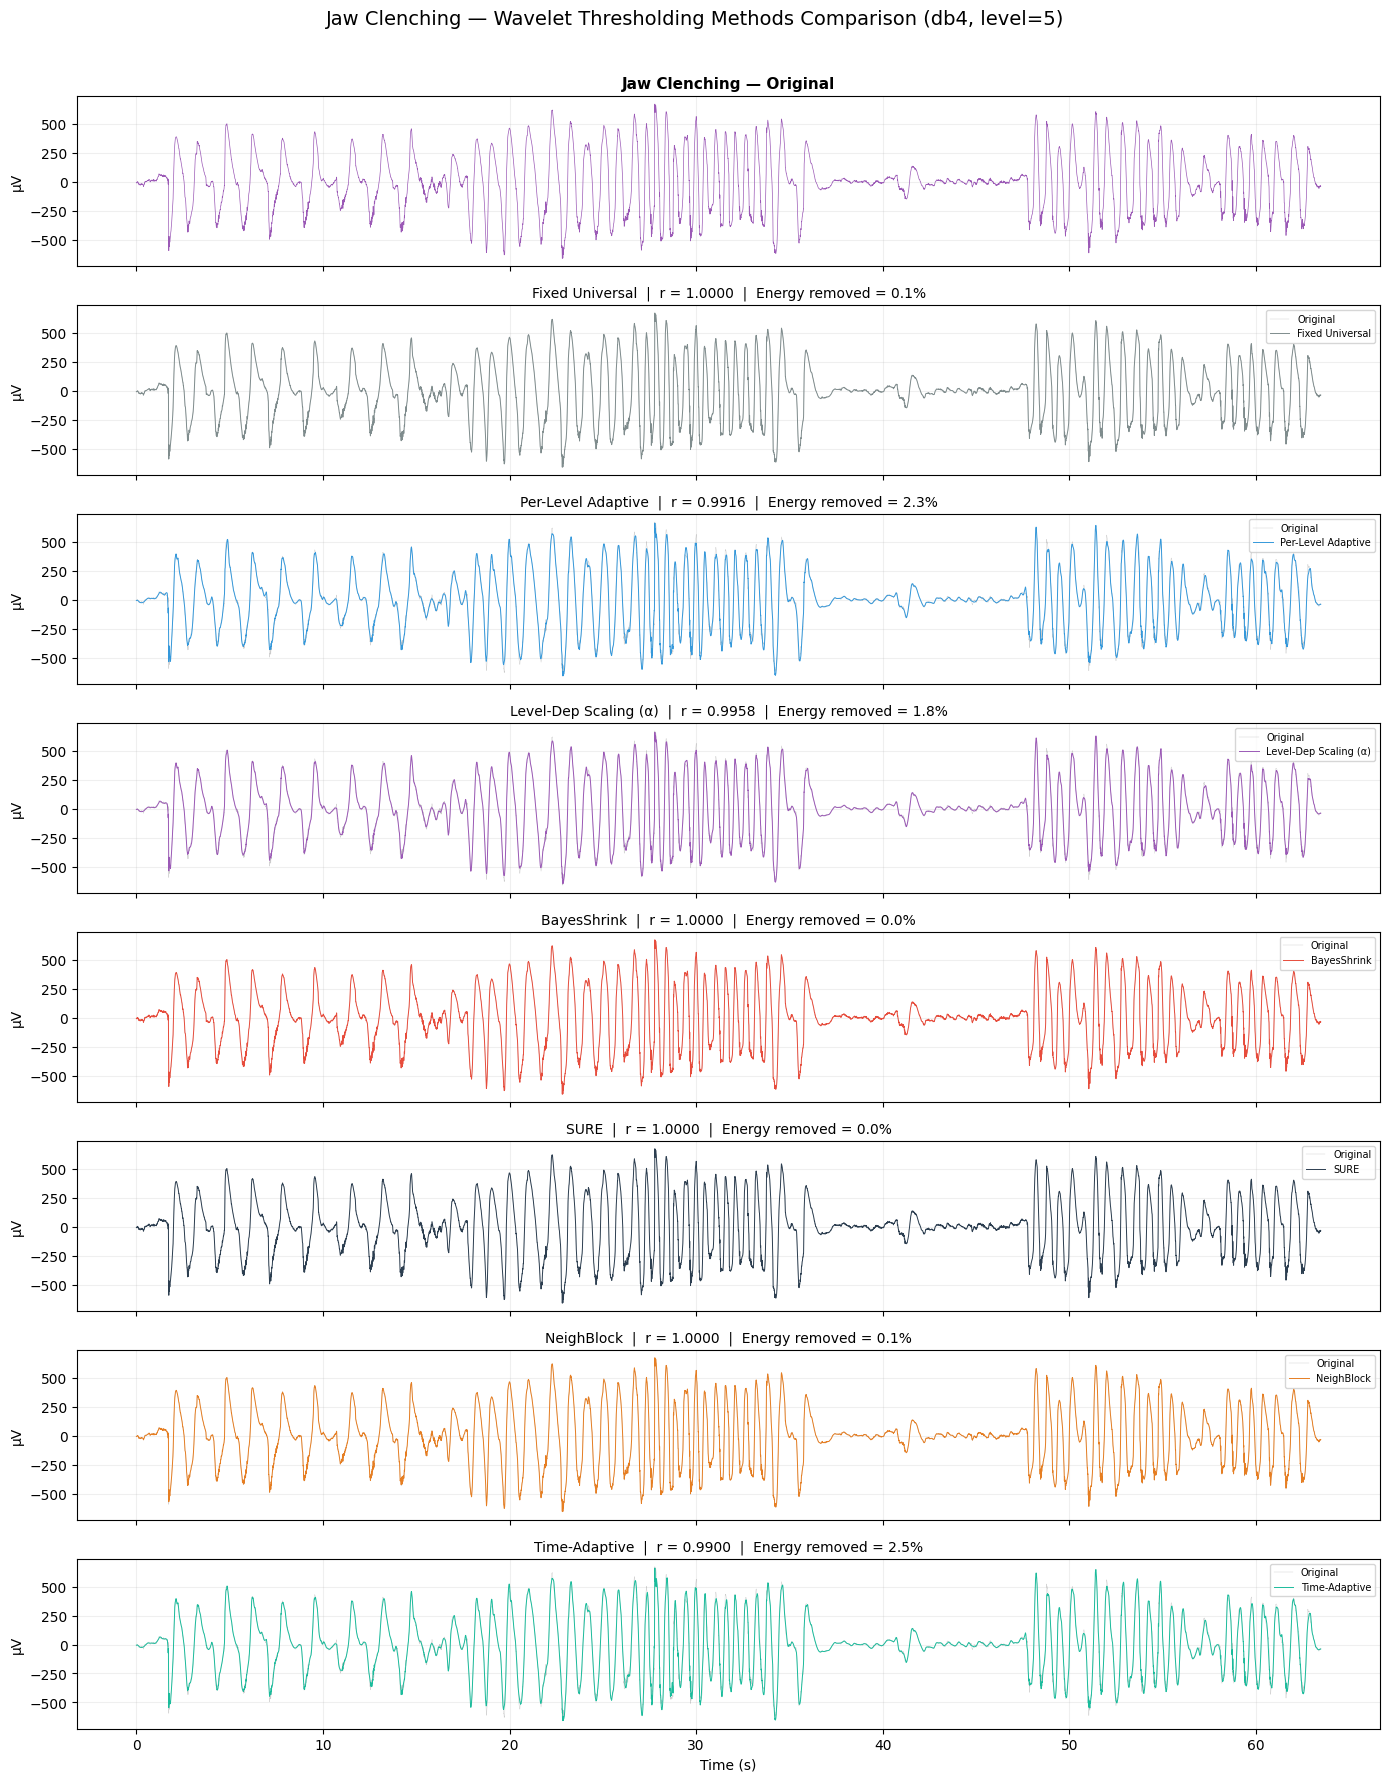

In [15]:
# ═══════════════════════════════════════════════════════════════════════
# WAVELET THRESHOLDING — 6 Methods Compared
# ═══════════════════════════════════════════════════════════════════════

# --- Method 1: Fixed Universal (VisuShrink) ---
def wt_fixed(sig, wavelet='db4', level=5):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(sig)))
    ct = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(ct, wavelet)[:len(sig)]

# --- Method 2: Per-Level Adaptive ---
def wt_perlevel(sig, wavelet='db4', level=5):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    ct = [coeffs[0]]
    for d in coeffs[1:]:
        sigma_j = np.median(np.abs(d)) / 0.6745
        thresh_j = sigma_j * np.sqrt(2 * np.log(len(d)))
        ct.append(pywt.threshold(d, value=thresh_j, mode='soft'))
    return pywt.waverec(ct, wavelet)[:len(sig)]

# --- Method 3: Level-Dependent Scaling (alpha_j) ---
def wt_scaled(sig, wavelet='db4', level=5):
    alphas = [0.5, 0.7, 1.0, 1.3, 1.5]  # D5→D1: low freq gets gentle threshold
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    ct = [coeffs[0]]
    for d, alpha in zip(coeffs[1:], alphas):
        sigma_j = np.median(np.abs(d)) / 0.6745
        thresh_j = alpha * sigma_j * np.sqrt(2 * np.log(len(d)))
        ct.append(pywt.threshold(d, value=thresh_j, mode='soft'))
    return pywt.waverec(ct, wavelet)[:len(sig)]

# --- Method 4: BayesShrink ---
def wt_bayes(sig, wavelet='db4', level=5):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma_n = np.median(np.abs(coeffs[-1])) / 0.6745
    ct = [coeffs[0]]
    for d in coeffs[1:]:
        sigma_d2 = np.mean(d**2)
        sigma_x = np.sqrt(max(sigma_d2 - sigma_n**2, 0))
        thresh_j = np.max(np.abs(d)) if sigma_x == 0 else sigma_n**2 / sigma_x
        ct.append(pywt.threshold(d, value=thresh_j, mode='soft'))
    return pywt.waverec(ct, wavelet)[:len(sig)]

# --- Method 5: NeighBlock ---
def neighblock_threshold(d, sigma_n, block_size=None):
    N = len(d)
    if block_size is None:
        block_size = max(1, int(np.sqrt(N)))
    thresh = sigma_n * np.sqrt(2 * np.log(N))
    d_out = d.copy()
    for start in range(0, N, block_size):
        end = min(start + block_size, N)
        block = d[start:end]
        block_energy = np.sqrt(np.sum(block**2))
        if block_energy <= thresh * np.sqrt(len(block)):
            d_out[start:end] = 0.0
        else:
            factor = max(0, 1 - (thresh * np.sqrt(len(block))) / block_energy)
            d_out[start:end] = block * factor
    return d_out

def wt_neighblock(sig, wavelet='db4', level=5):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma_n = np.median(np.abs(coeffs[-1])) / 0.6745
    ct = [coeffs[0]]
    for d in coeffs[1:]:
        ct.append(neighblock_threshold(d, sigma_n))
    return pywt.waverec(ct, wavelet)[:len(sig)]

# --- Method 6: Time-Adaptive (Windowed) ---
def time_adaptive_threshold(d, window_size=None):
    N = len(d)
    if window_size is None:
        window_size = max(8, N // 4)
    d_out = d.copy()
    half_win = window_size // 2
    for i in range(N):
        start = max(0, i - half_win)
        end = min(N, i + half_win)
        local = d[start:end]
        sigma_local = np.median(np.abs(local)) / 0.6745
        thresh_local = sigma_local * np.sqrt(2 * np.log(len(local)))
        if np.abs(d[i]) < thresh_local:
            d_out[i] = 0.0
        else:
            d_out[i] = np.sign(d[i]) * (np.abs(d[i]) - thresh_local)
    return d_out

# --- Method 7: SURE (Stein's Unbiased Risk Estimate) ---
def sure_threshold(d):
    """Compute the optimal threshold minimizing SURE risk."""
    N = len(d)
    d_sorted = np.sort(np.abs(d))**2
    risks = np.zeros(N)
    for i in range(N):
        thresh2 = d_sorted[i]
        # Number of coefficients below threshold
        n_below = i + 1
        # SURE risk formula
        risks[i] = (N - 2 * n_below + np.sum(np.minimum(d_sorted, thresh2))) / N
    best_idx = np.argmin(risks)
    return np.sqrt(d_sorted[best_idx])

def wt_sure(sig, wavelet='db4', level=5):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    ct = [coeffs[0]]
    for d in coeffs[1:]:
        thresh_j = sure_threshold(d)
        ct.append(pywt.threshold(d, value=thresh_j, mode='soft'))
    return pywt.waverec(ct, wavelet)[:len(sig)]

def wt_timeadapt(sig, wavelet='db4', level=5):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    ct = [coeffs[0]]
    for d in coeffs[1:]:
        ct.append(time_adaptive_threshold(d))
    return pywt.waverec(ct, wavelet)[:len(sig)]

# ═══════════════════════════════════════════════════════════════════════
# APPLY ALL METHODS TO ALL THREE ARTIFACTS
# ═══════════════════════════════════════════════════════════════════════
wt_methods = {
    'Fixed Universal':       wt_fixed,
    'Per-Level Adaptive':    wt_perlevel,
    'Level-Dep Scaling (α)': wt_scaled,
    'BayesShrink':           wt_bayes,
    'SURE':                  wt_sure,
    'NeighBlock':            wt_neighblock,
    'Time-Adaptive':         wt_timeadapt,
}

method_colors_wt = {
    'Fixed Universal':       '#7f8c8d',
    'Per-Level Adaptive':    '#3498db',
    'Level-Dep Scaling (α)': '#9b59b6',
    'BayesShrink':           '#e74c3c',
    'SURE':                  '#2c3e50',
    'NeighBlock':            '#e67e22',
    'Time-Adaptive':         '#1abc9c',
}


# Store all results
wt_all_results = {}
for name, (sig, t) in artifacts.items():
    wt_all_results[name] = {}
    for method_name, method_fn in wt_methods.items():
        wt_all_results[name][method_name] = method_fn(sig)

# Also store the Fixed Universal result for the comparison cell later
wt_results = {}
for name in artifacts:
    wt_results[name] = wt_all_results[name]['Fixed Universal']

# ═══════════════════════════════════════════════════════════════════════
# METRICS TABLE
# ═══════════════════════════════════════════════════════════════════════
print(f'{"Artifact":<18} {"Method":<25} {"Energy Removed (%)":>20} {"Corr w/ Original":>18}')
print('=' * 85)

for name, (sig, t) in artifacts.items():
    for method_name in wt_methods:
        recon = wt_all_results[name][method_name]
        energy_removed = (1 - np.sum(recon**2) / np.sum(sig**2)) * 100
        corr = np.corrcoef(sig, recon)[0, 1]
        print(f'{name:<18} {method_name:<25} {energy_removed:>18.1f}% {corr:>18.4f}')
    print('-' * 85)

# ═══════════════════════════════════════════════════════════════════════
# PLOT: For each artifact, show original + all 6 denoised methods
# ═══════════════════════════════════════════════════════════════════════
for name, (sig, t) in artifacts.items():
    n_methods = len(wt_methods)
    fig, axes = plt.subplots(n_methods + 1, 1, figsize=(14, 2.2 * (n_methods + 1)), sharex=True)

    # Row 0: Original
    axes[0].plot(t, sig, color=colors[name], linewidth=0.5)
    axes[0].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('µV')
    axes[0].grid(alpha=0.2)

    # Rows 1+: Each method
    for idx, (method_name, method_fn) in enumerate(wt_methods.items()):
        recon = wt_all_results[name][method_name]
        energy_removed = (1 - np.sum(recon**2) / np.sum(sig**2)) * 100
        corr = np.corrcoef(sig, recon)[0, 1]

        ax = axes[idx + 1]
        ax.plot(t, sig, color='gray', linewidth=0.3, alpha=0.4, label='Original')
        ax.plot(t, recon, color=method_colors_wt[method_name], linewidth=0.7,
                label=method_name)
        ax.set_title(f'{method_name}  |  r = {corr:.4f}  |  Energy removed = {energy_removed:.1f}%',
                     fontsize=10)
        ax.set_ylabel('µV')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'{name} — Wavelet Thresholding Methods Comparison (db4, level=5)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


## 4. EMD — Empirical Mode Decomposition
---
EMD decomposes each signal into **Intrinsic Mode Functions (IMFs)**. We reconstruct by **removing the first IMF** (highest frequency, typically noise/artifact) and summing the rest.


  Eye Blinks  (11 IMFs, kurtosis threshold = 3.0)
   IMF Sample Entropy Kurtosis Decision
 IMF 1         0.7472   1.5909     KEEP
 IMF 2         0.6493   5.7855   REJECT
 IMF 3         0.4762   8.7191   REJECT
 IMF 4         0.4106   4.3207   REJECT
 IMF 5         0.1033   3.9558   REJECT
 IMF 6         0.0299   2.0816     KEEP
 IMF 7         0.0124   1.4403     KEEP
 IMF 8         0.0117   0.9788     KEEP
 IMF 9         0.0044  -0.7330     KEEP
IMF 10         0.0054  -1.0652     KEEP
IMF 11         0.0035  -0.4127     KEEP

Removed IMFs: 2,3,4,5
Kept IMFs:    1,6,7,8,9,10,11

  Head Nodding  (12 IMFs, kurtosis threshold = 3.0)
   IMF Sample Entropy Kurtosis Decision
 IMF 1         0.5806  45.6429   REJECT
 IMF 2         0.5745  37.0536   REJECT
 IMF 3         0.5313  22.4757   REJECT
 IMF 4         0.5055  10.3432   REJECT
 IMF 5         0.2955   9.9050   REJECT
 IMF 6         0.1107   6.4015   REJECT
 IMF 7         0.0312   3.2071   REJECT
 IMF 8         0.0180   2.6187     KEEP
 IM

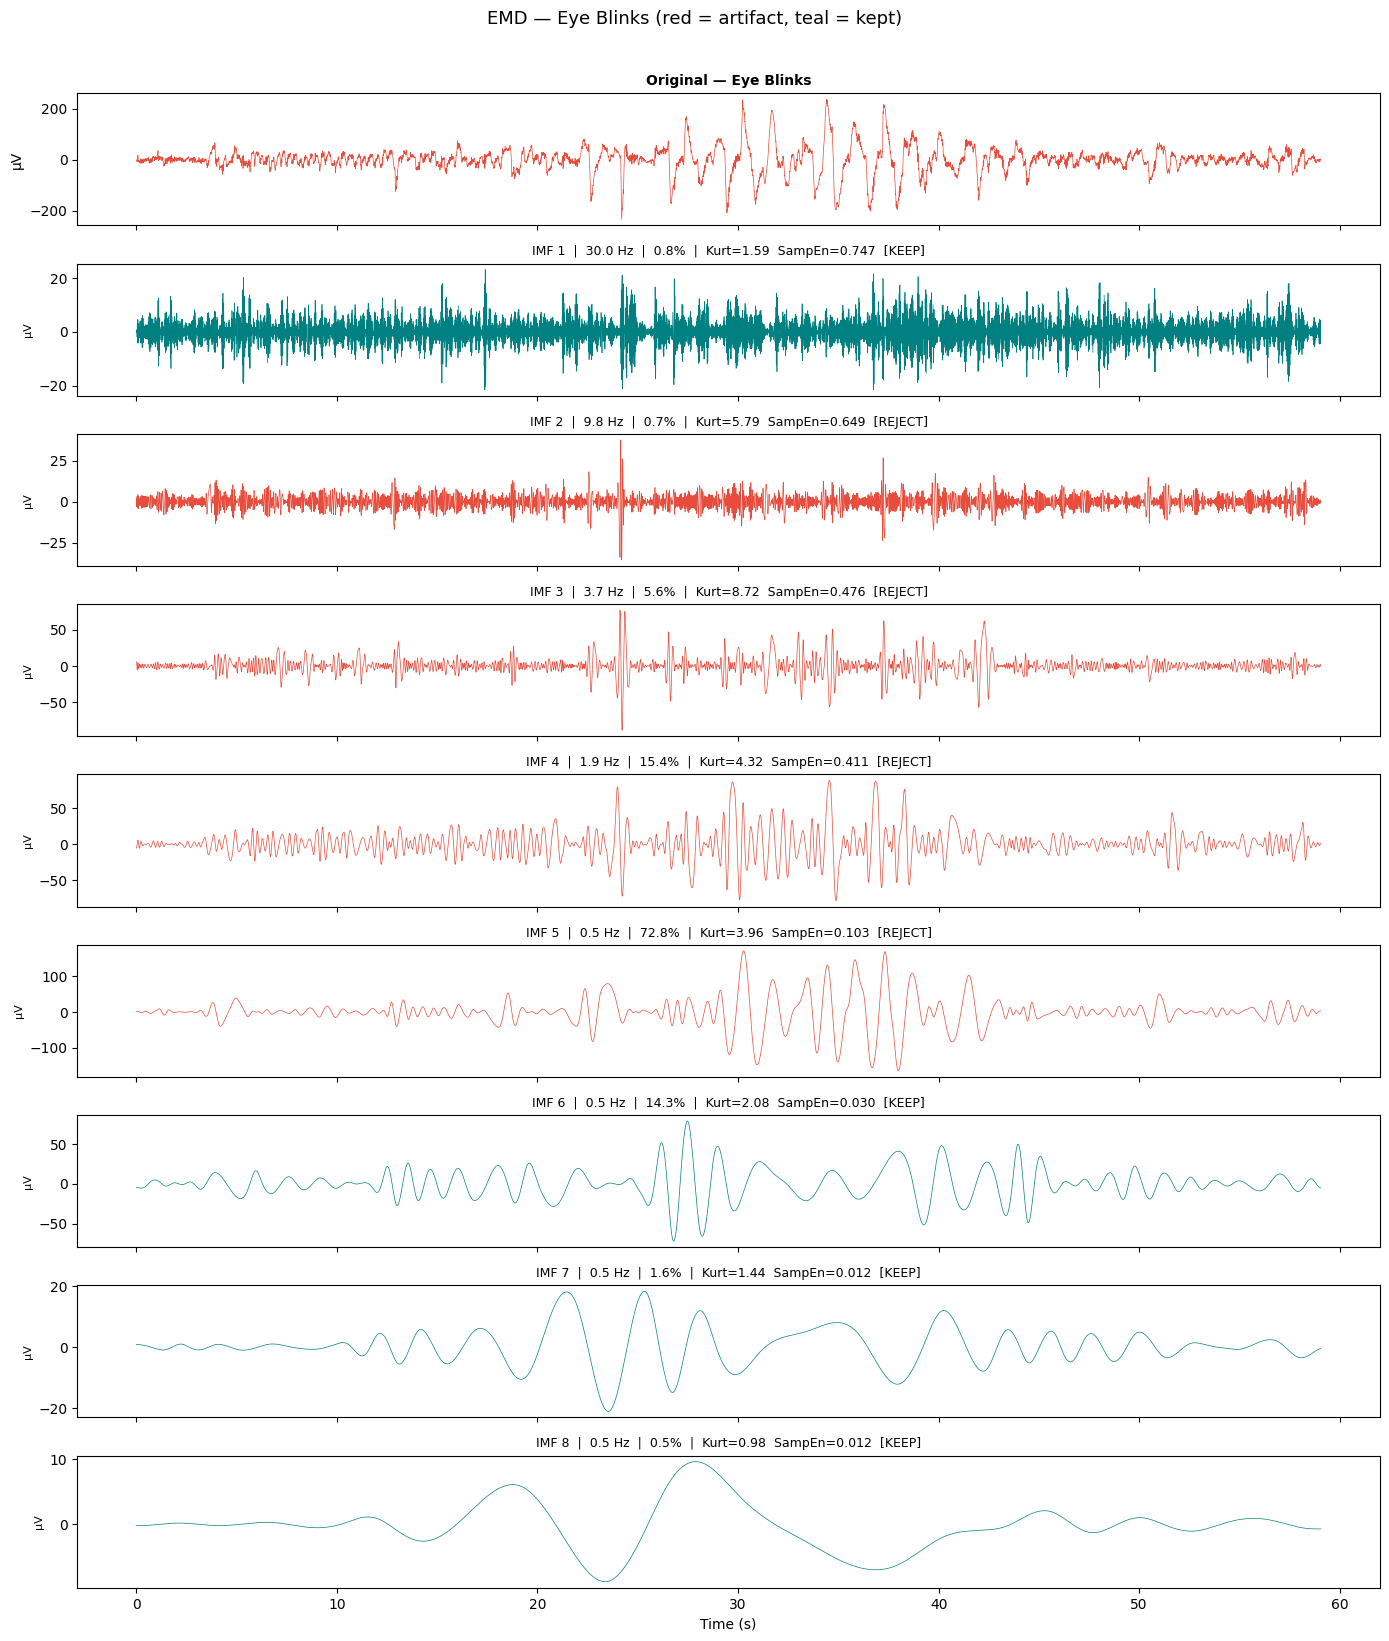

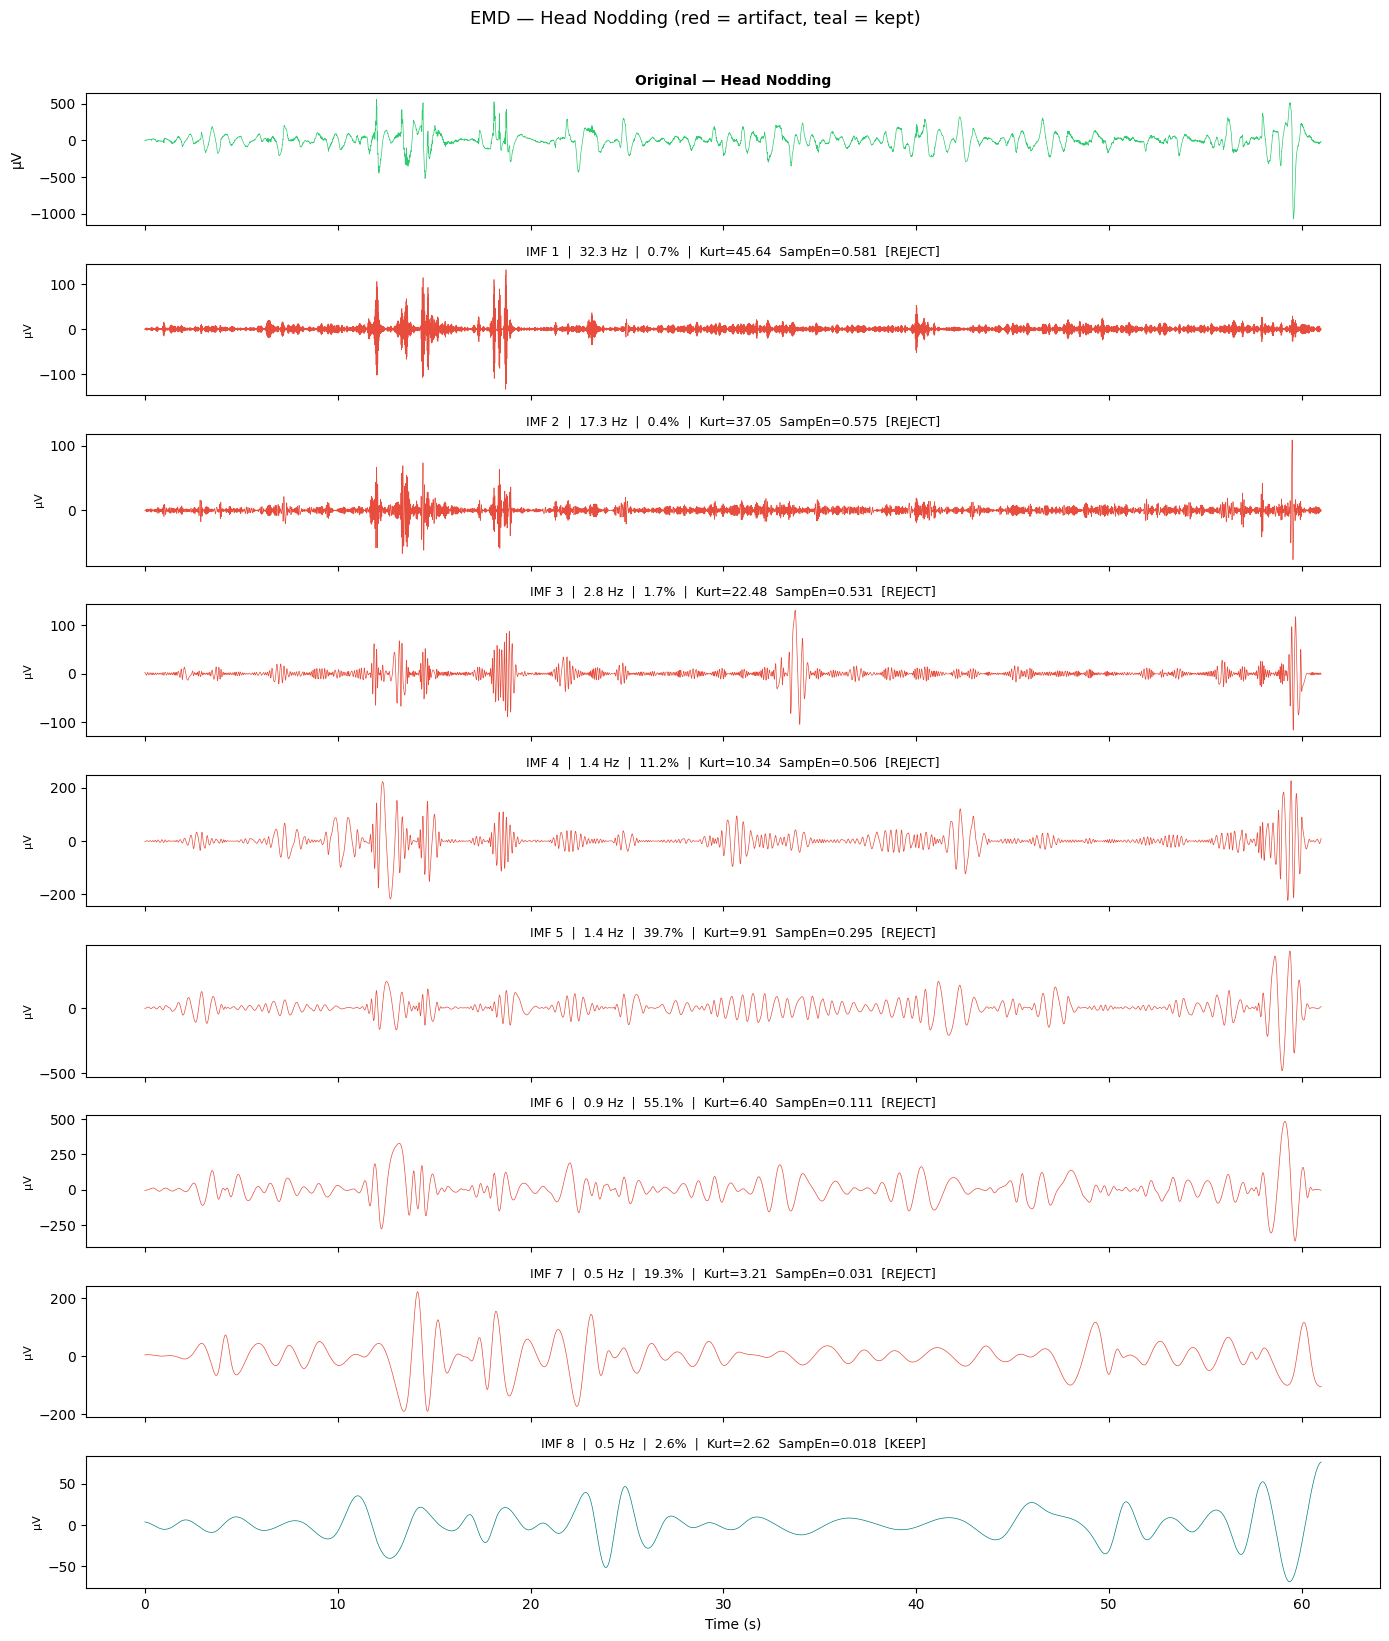

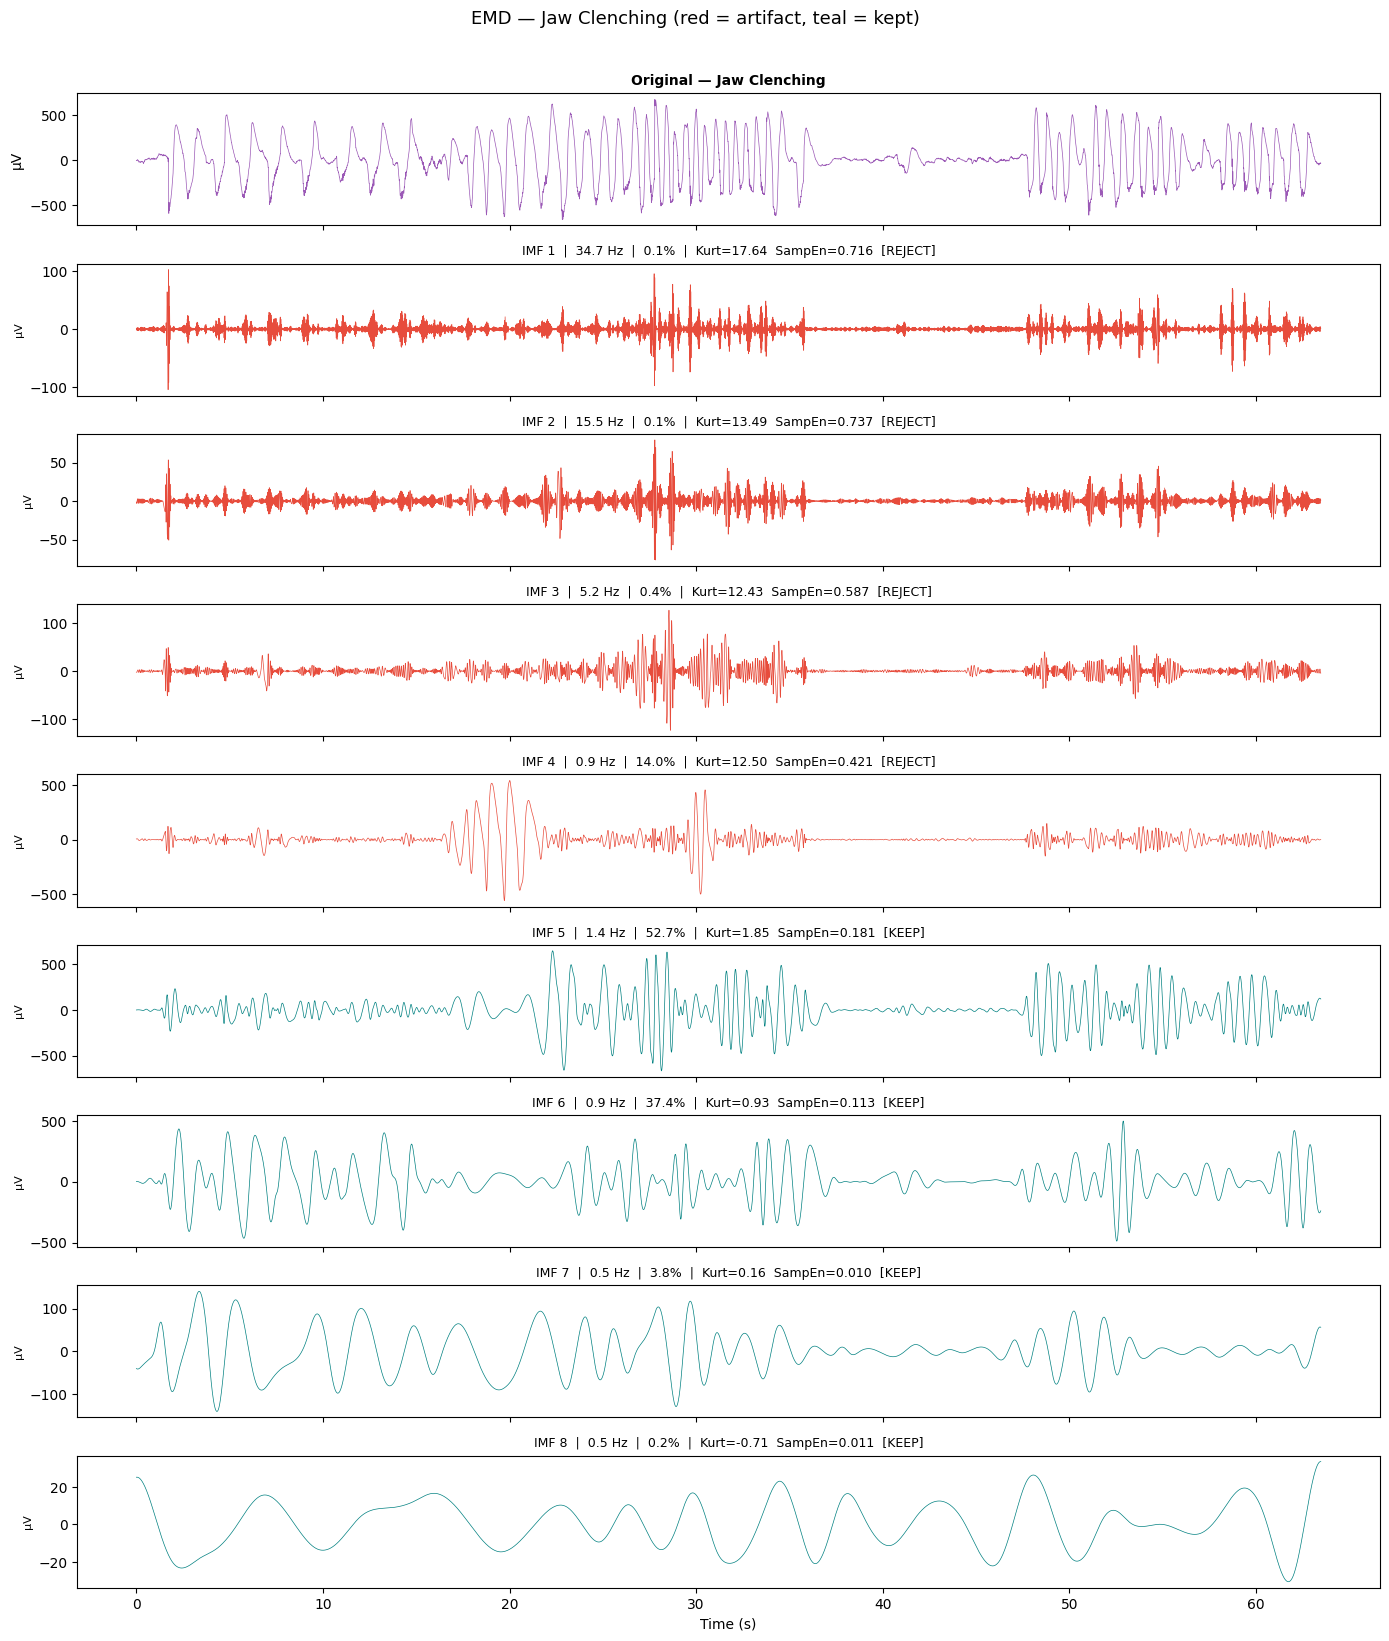

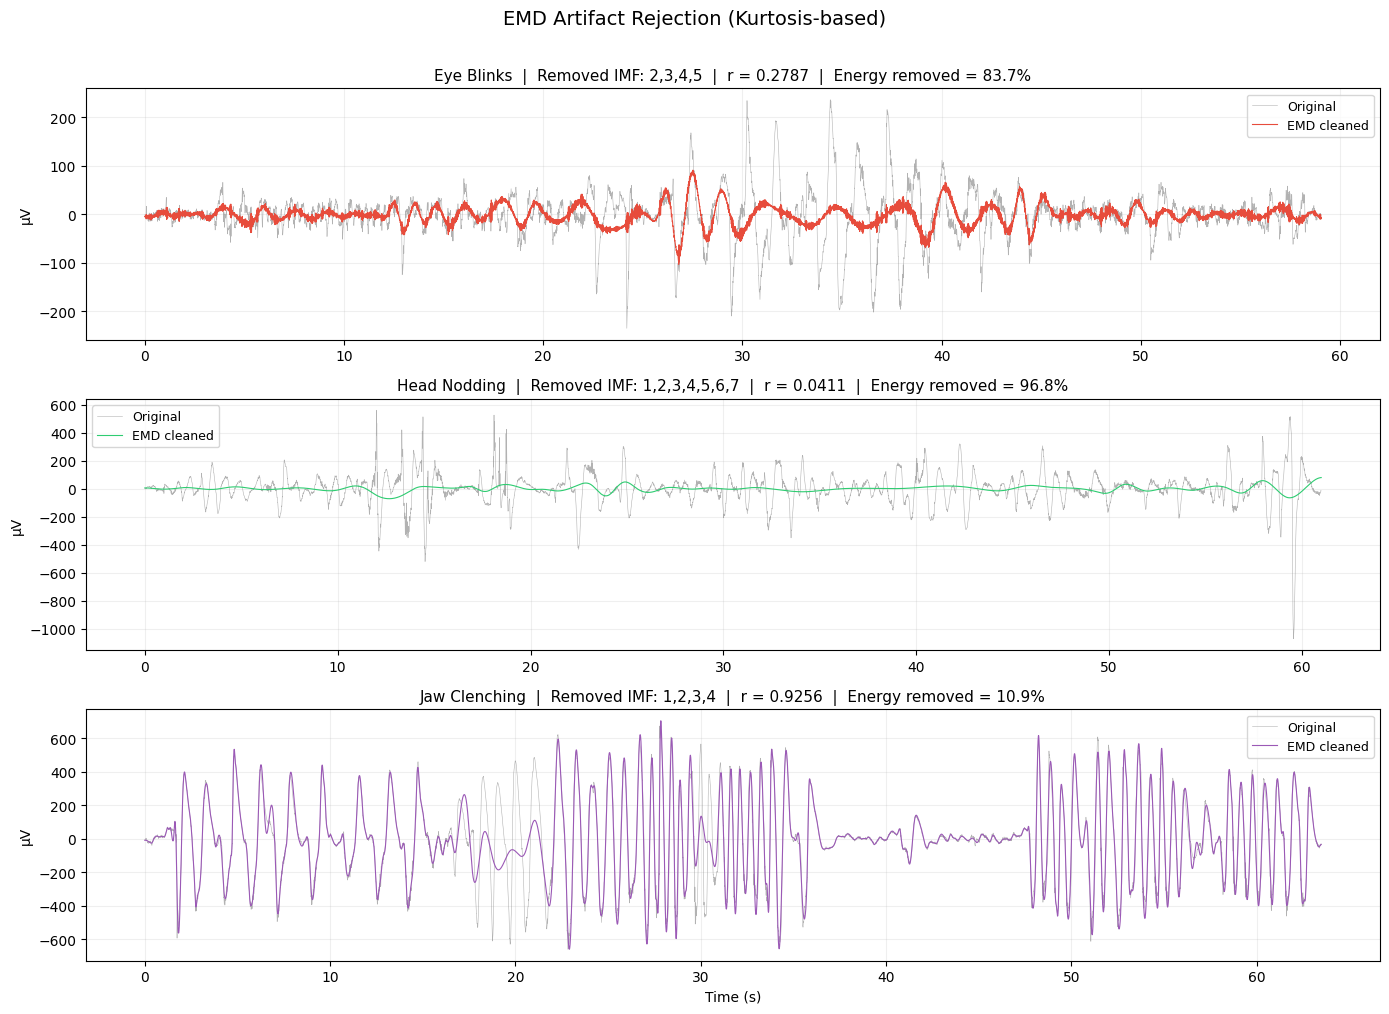

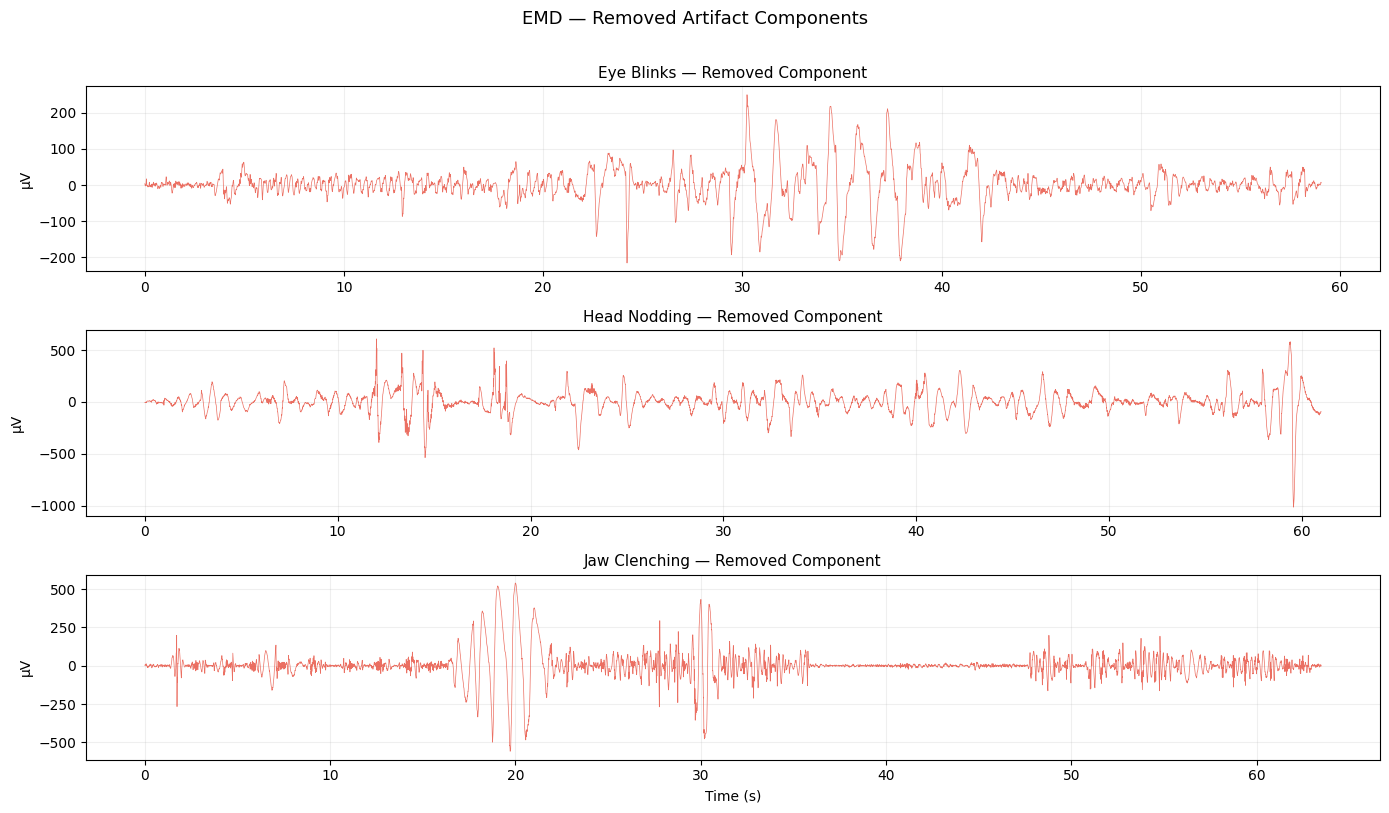

In [16]:
from scipy.stats import kurtosis
import pandas as pd

def sample_entropy(x, m=2, r_frac=0.2):
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = r_frac * np.std(x)
    if r == 0 or N < m + 2:
        return 0.0
    def _count(tl):
        templates = np.lib.stride_tricks.sliding_window_view(x, tl)
        count = 0
        for i in range(len(templates)):
            dists = np.max(np.abs(templates[i] - templates), axis=1)
            count += np.sum(dists < r) - 1
        return count
    A, B = _count(m + 1), _count(m)
    if B == 0 or A == 0:
        return 0.0
    return -np.log(A / B)

def emd_denoise(sig, t, n_remove=1):
    """EMD decomposition, reconstruct by removing first n_remove IMFs."""
    emd_obj = EMD()
    imfs = emd_obj.emd(sig, t)
    reconstructed = np.sum(imfs[n_remove:], axis=0)
    return imfs, reconstructed

kurt_threshold = 3.0  # IMFs with |kurtosis| > this are flagged as artifact

emd_results = {}
emd_imfs_all = {}
emd_keep_masks = {}

for name, (sig, t) in artifacts.items():
    imfs, _ = emd_denoise(sig, t)
    emd_imfs_all[name] = imfs
    n_imfs = imfs.shape[0]

    # Compute metrics
    entropies = [sample_entropy(imf[:300]) for imf in imfs]
    kurts = [kurtosis(imf) for imf in imfs]

    # Kurtosis-based rejection
    kurts_arr = np.array(kurts)
    keep_mask = np.abs(kurts_arr) < kurt_threshold
    emd_keep_masks[name] = keep_mask

    # Reconstruct using only kept IMFs
    reconstructed = np.sum(imfs[keep_mask], axis=0)
    emd_results[name] = reconstructed

    # ── Print table ──────────────────────────────────────────────────
    print(f'\n{"="*60}')
    print(f'  {name}  ({n_imfs} IMFs, kurtosis threshold = {kurt_threshold})')
    print(f'{"="*60}')

    rows = []
    for i in range(n_imfs):
        tag = "KEEP" if keep_mask[i] else "REJECT"
        rows.append({
            'IMF': f'IMF {i+1}',
            'Sample Entropy': f'{entropies[i]:.4f}',
            'Kurtosis': f'{kurts_arr[i]:.4f}',
            'Decision': tag,
        })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    removed_ids = [str(i+1) for i in range(n_imfs) if not keep_mask[i]]
    kept_ids = [str(i+1) for i in range(n_imfs) if keep_mask[i]]
    print(f'\nRemoved IMFs: {",".join(removed_ids) if removed_ids else "none"}')
    print(f'Kept IMFs:    {",".join(kept_ids)}')

# ═══════════════════════════════════════════════════════════════════════
# PLOT IMFs — coloured by keep/reject
# ═══════════════════════════════════════════════════════════════════════
for name, (sig, t) in artifacts.items():
    imfs = emd_imfs_all[name]
    keep_mask = emd_keep_masks[name]
    n_imfs = min(imfs.shape[0], 8)

    kurts_arr = np.array([kurtosis(imf) for imf in imfs])
    entropies = [sample_entropy(imf[:300]) for imf in imfs]

    fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 1.8 * (n_imfs + 1)), sharex=True)

    axes[0].plot(t, sig, color=colors[name], linewidth=0.5)
    axes[0].set_title(f'Original — {name}', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('µV')

    for i in range(n_imfs):
        f_psd, psd = welch(imfs[i], fs=fs, nperseg=min(512, len(imfs[i])))
        dom_freq = f_psd[np.argmax(psd)]
        energy_pct = np.sum(imfs[i]**2) / np.sum(sig**2) * 100

        is_artifact = not keep_mask[i]
        color = '#e74c3c' if is_artifact else 'teal'
        tag = 'REJECT' if is_artifact else 'KEEP'

        axes[i+1].plot(t, imfs[i], color=color, linewidth=0.5)
        axes[i+1].set_title(
            f'IMF {i+1}  |  {dom_freq:.1f} Hz  |  {energy_pct:.1f}%  |  '
            f'Kurt={kurts_arr[i]:.2f}  SampEn={entropies[i]:.3f}  [{tag}]',
            fontsize=9)
        axes[i+1].set_ylabel('µV', fontsize=8)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'EMD — {name} (red = artifact, teal = kept)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT: Original vs Cleaned for each artifact
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (name, (sig, t)) in zip(axes, artifacts.items()):
    recon = emd_results[name]
    keep_mask = emd_keep_masks[name]
    kept_ids = ",".join(str(i+1) for i in range(len(keep_mask)) if keep_mask[i])
    removed_ids = ",".join(str(i+1) for i in range(len(keep_mask)) if not keep_mask[i])

    corr = np.corrcoef(sig, recon)[0, 1]
    energy_removed = (1 - np.sum(recon**2) / np.sum(sig**2)) * 100

    ax.plot(t, sig, color='gray', linewidth=0.4, alpha=0.6, label='Original')
    ax.plot(t, recon, color=colors[name], linewidth=0.8, label='EMD cleaned')
    ax.set_title(
        f'{name}  |  Removed IMF: {removed_ids if removed_ids else "none"}  |  '
        f'r = {corr:.4f}  |  Energy removed = {energy_removed:.1f}%',
        fontsize=11)
    ax.set_ylabel('µV')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EMD Artifact Rejection (Kurtosis-based)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT: Removed components
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for ax, (name, (sig, t)) in zip(axes, artifacts.items()):
    removed = sig - emd_results[name]
    ax.plot(t, removed, color='#e74c3c', linewidth=0.5, alpha=0.8)
    ax.set_title(f'{name} — Removed Component', fontsize=11)
    ax.set_ylabel('µV')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EMD — Removed Artifact Components', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5. EEMD — Ensemble EMD
---
EEMD adds white noise across multiple trials and averages the IMFs to reduce **mode mixing**. We use 50 trials with noise width 0.1.

Eye Blinks: 13 IMFs extracted
Head Nodding: 13 IMFs extracted
Jaw Clenching: 14 IMFs extracted


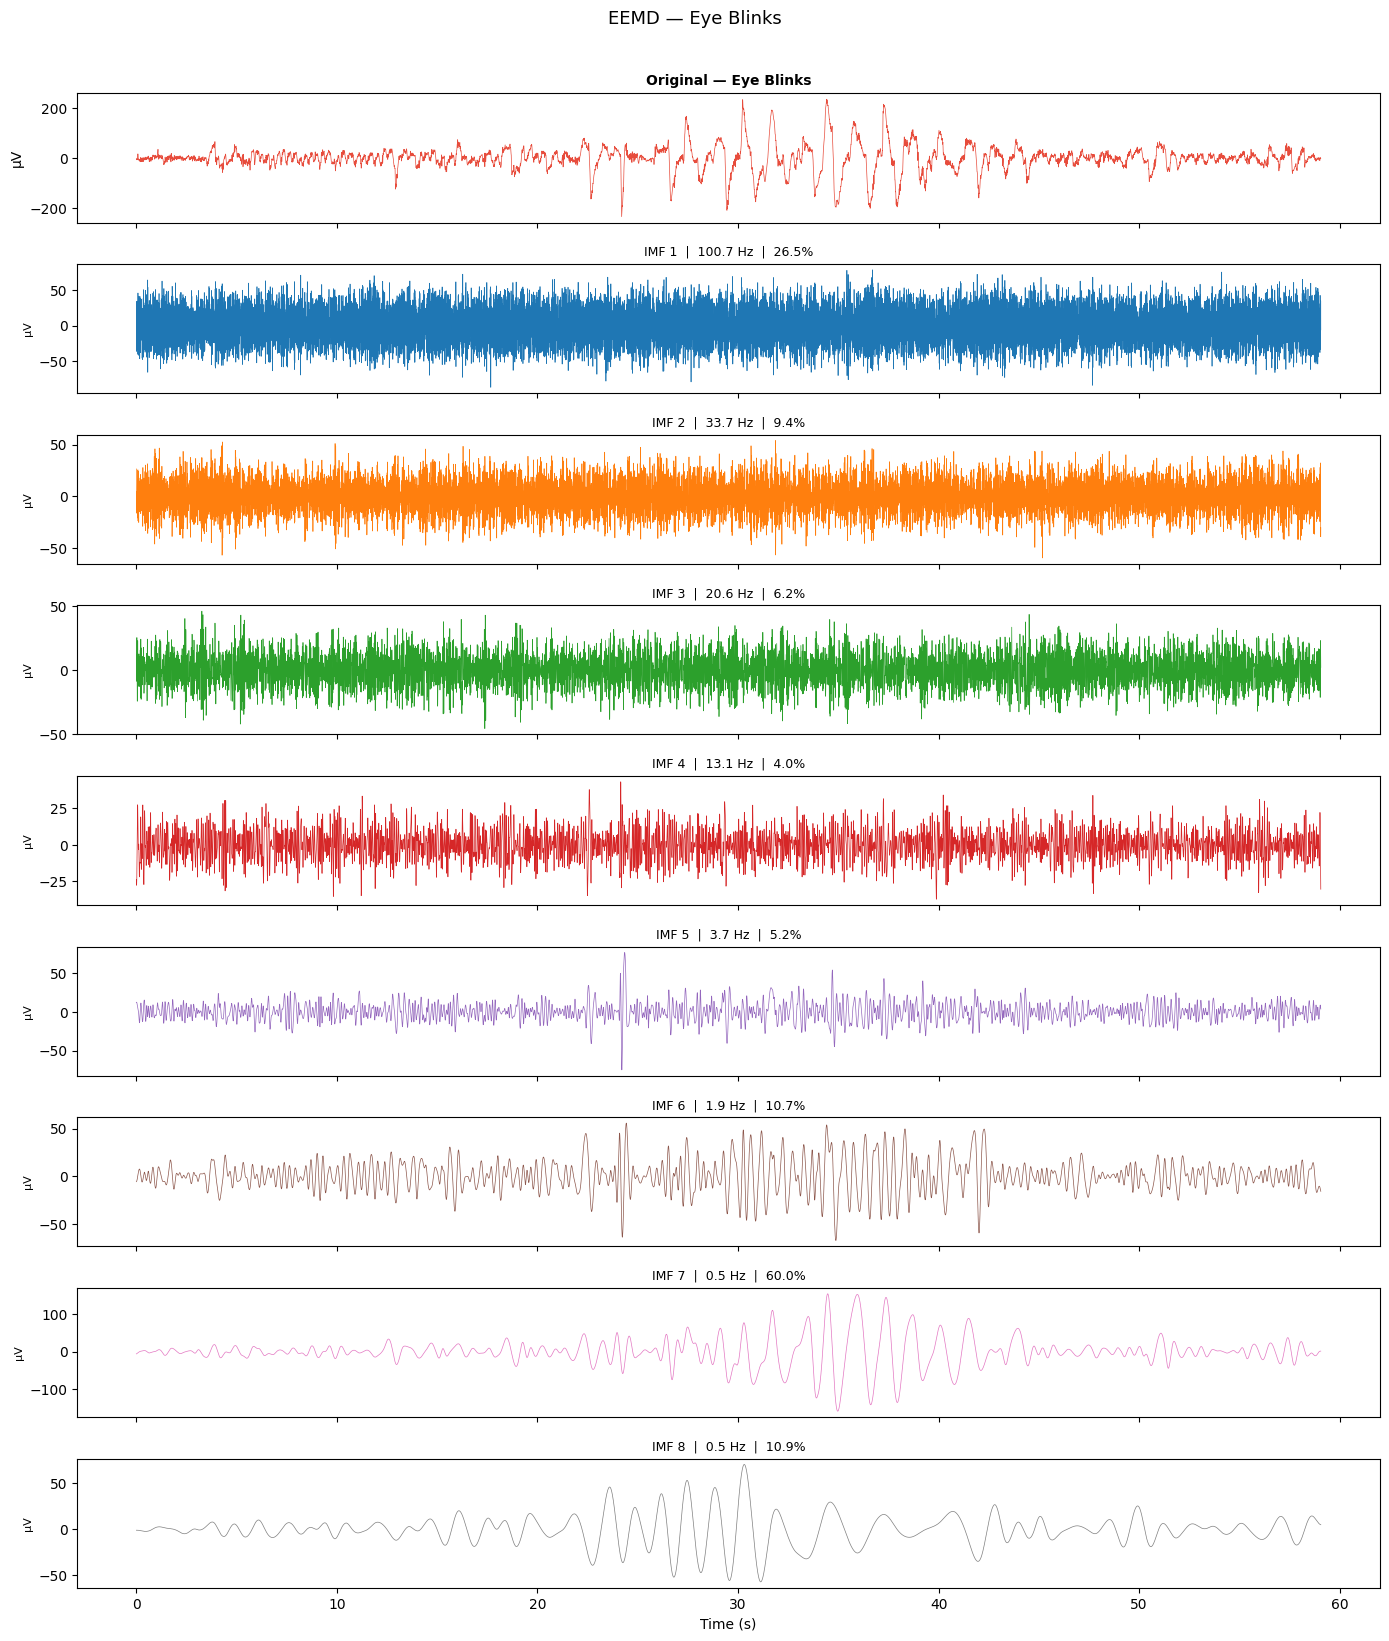

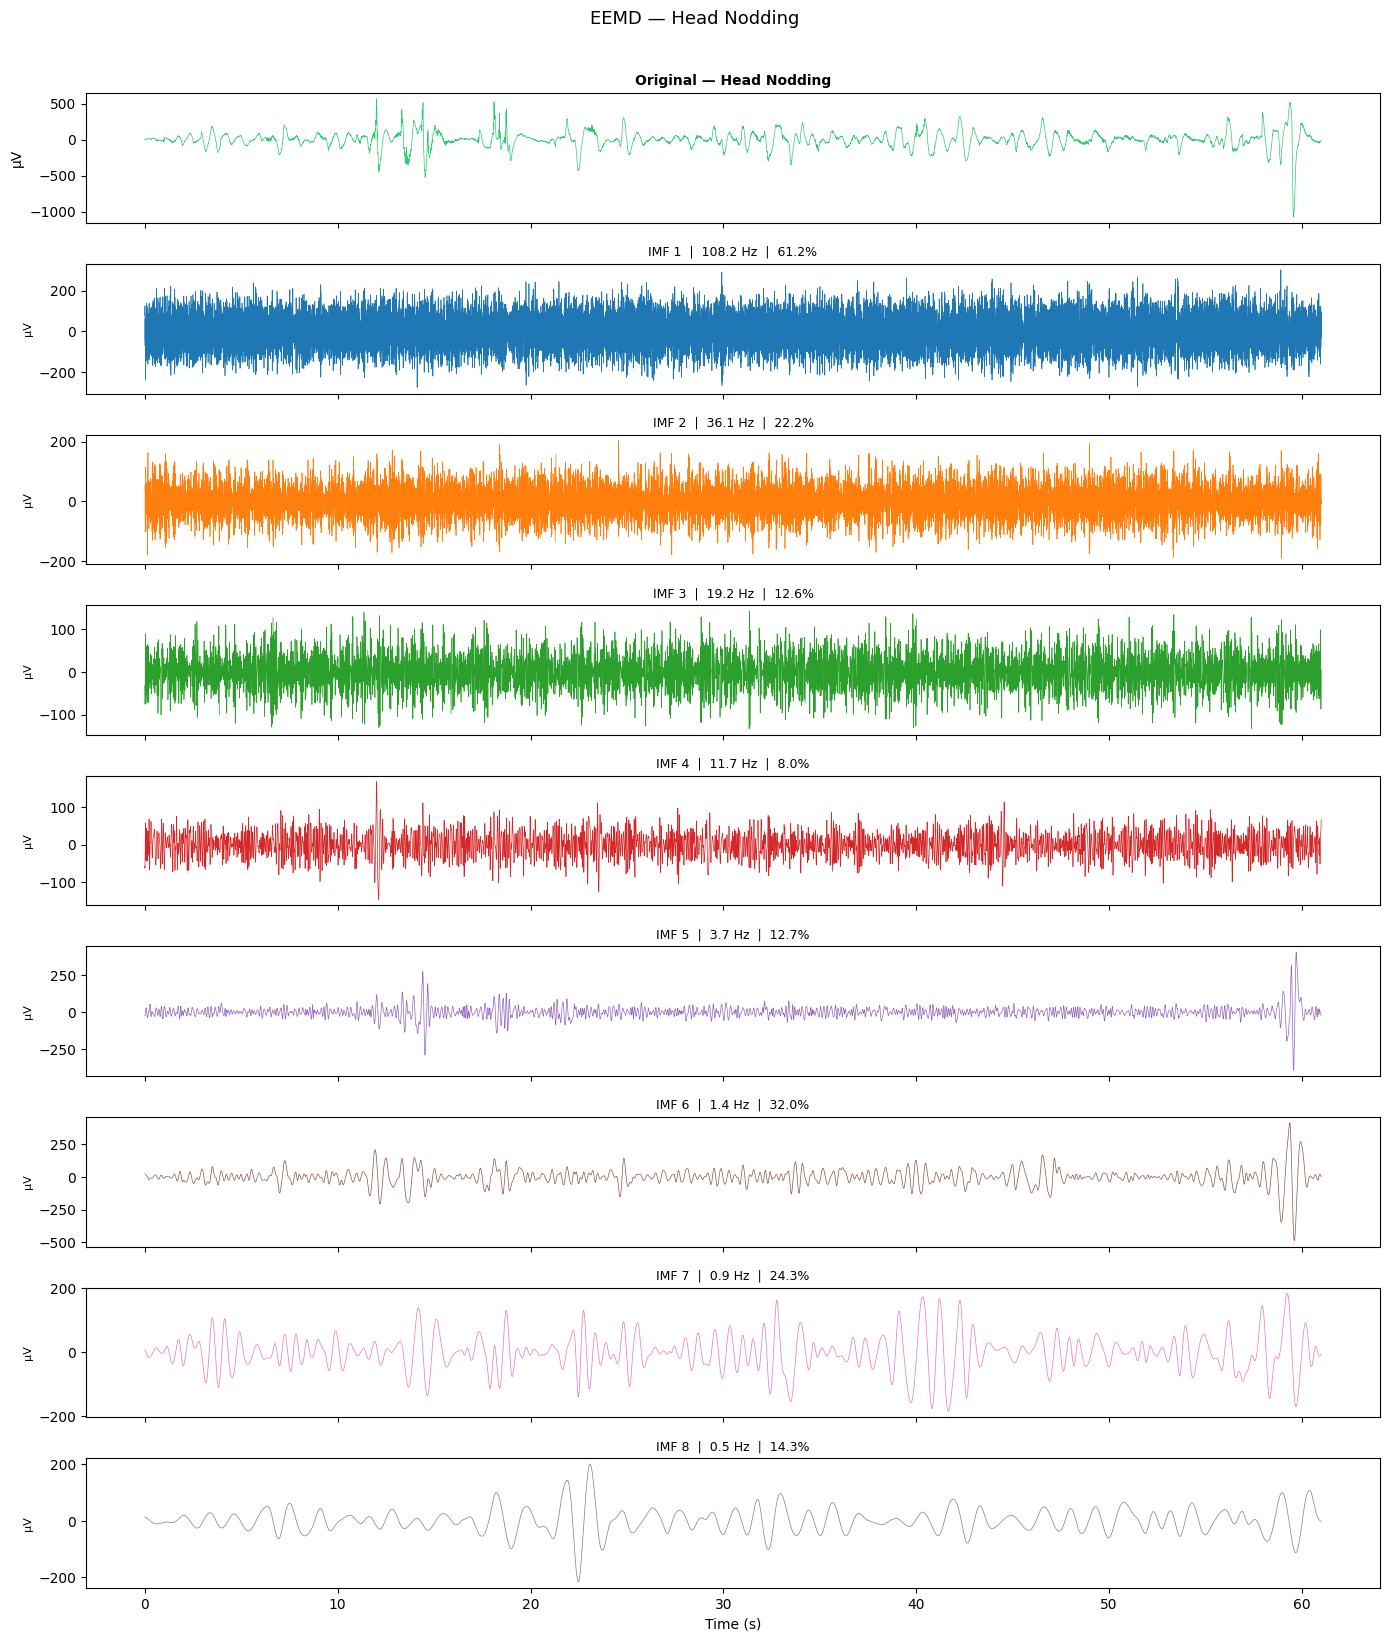

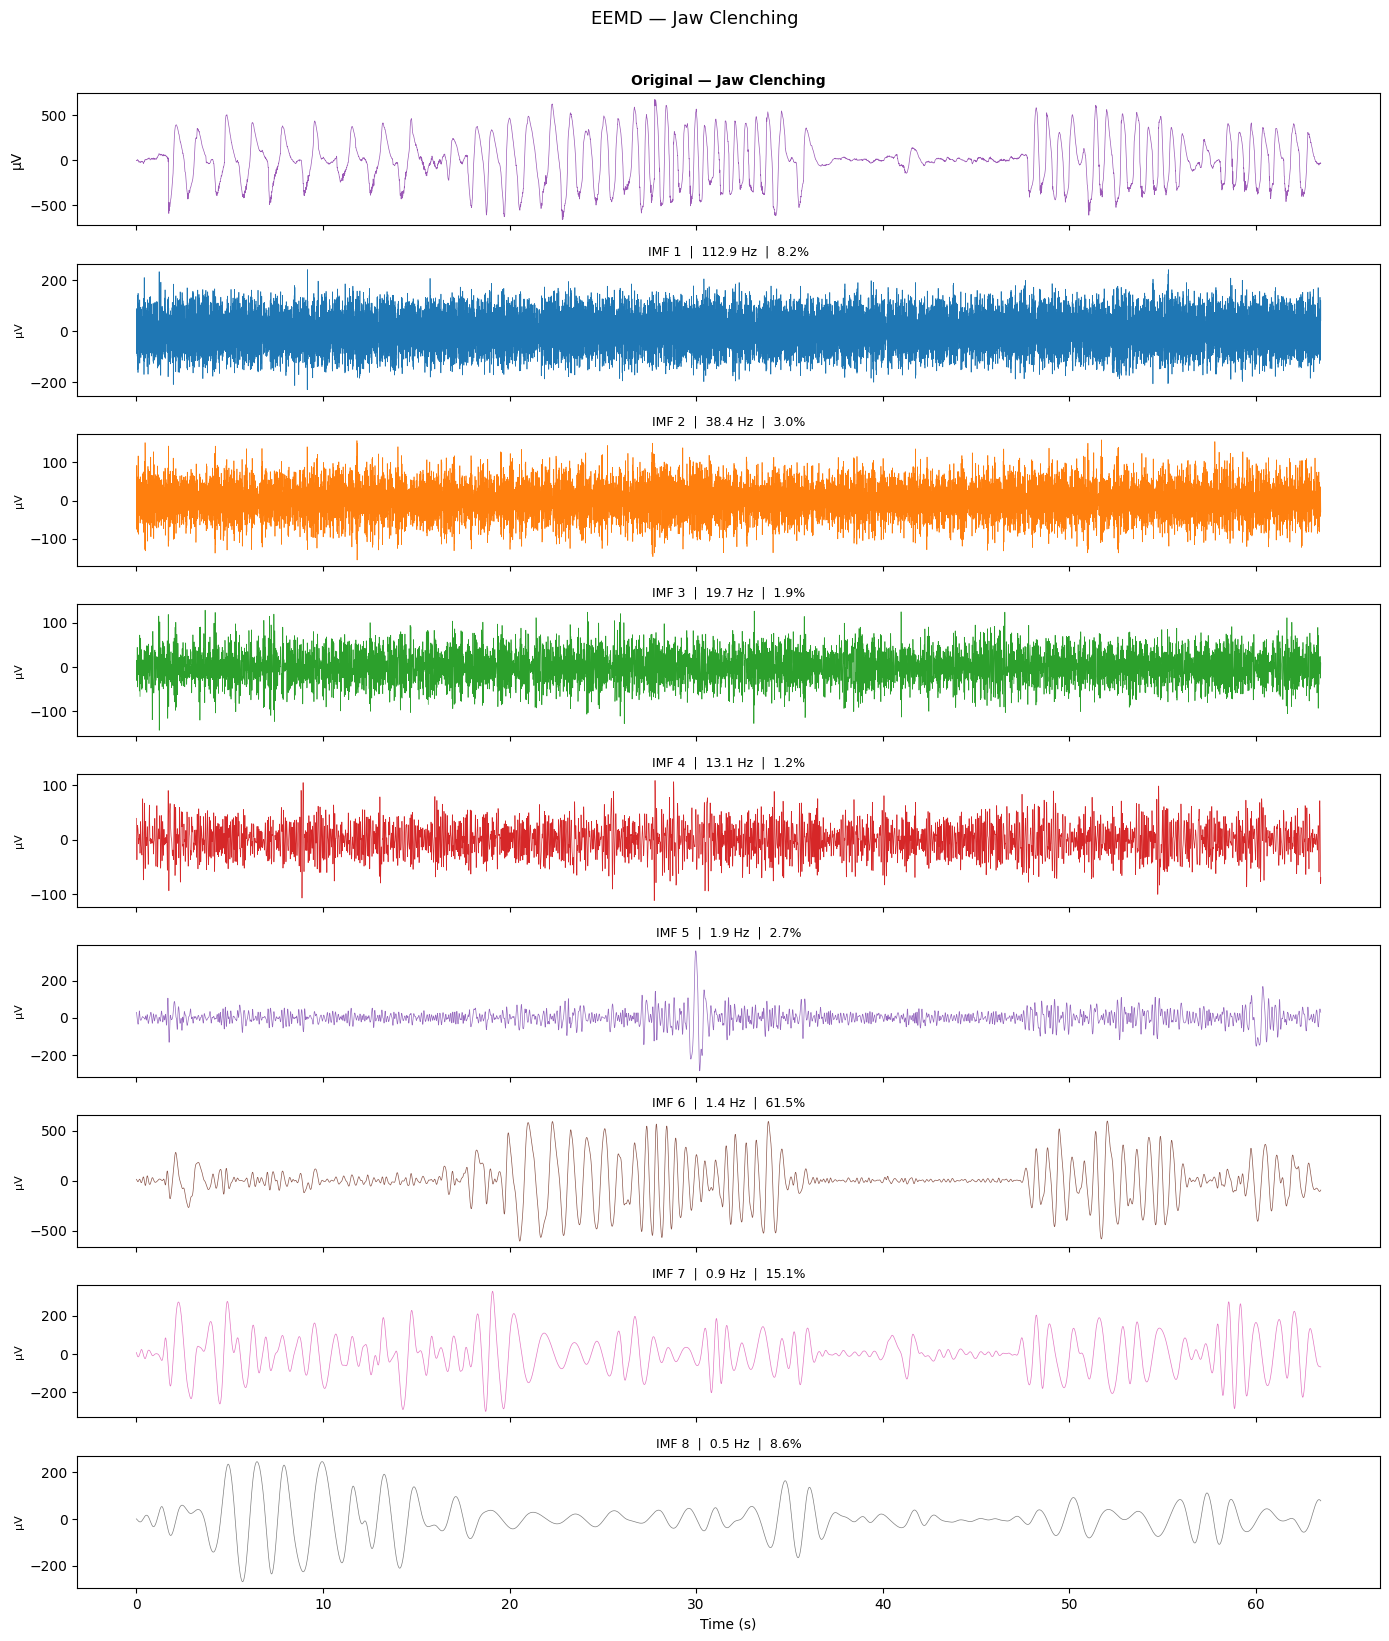

In [6]:
def eemd_denoise(sig, t, n_remove=1):
    """EEMD decomposition, reconstruct by removing first n_remove IMFs."""
    eemd = EEMD(trials=50, noise_width=0.1)
    imfs = eemd.eemd(sig, t)
    reconstructed = np.sum(imfs[n_remove:], axis=0)
    return imfs, reconstructed

eemd_results = {}
eemd_imfs_all = {}
for name, (sig, t) in artifacts.items():
    imfs, recon = eemd_denoise(sig, t)
    eemd_imfs_all[name] = imfs
    eemd_results[name] = recon
    print(f'{name}: {imfs.shape[0]} IMFs extracted')

# Plot IMFs for each artifact
for name, (sig, t) in artifacts.items():
    imfs = eemd_imfs_all[name]
    n_imfs = min(imfs.shape[0], 8)
    fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 1.8 * (n_imfs + 1)), sharex=True)

    axes[0].plot(t, sig, color=colors[name], linewidth=0.5)
    axes[0].set_title(f'Original — {name}', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('µV')

    for i in range(n_imfs):
        f_psd, psd = welch(imfs[i], fs=fs, nperseg=min(512, len(imfs[i])))
        dom_freq = f_psd[np.argmax(psd)]
        energy_pct = np.sum(imfs[i]**2) / np.sum(sig**2) * 100
        axes[i+1].plot(t, imfs[i], color=plt.cm.tab10(i), linewidth=0.5)
        axes[i+1].set_title(f'IMF {i+1}  |  {dom_freq:.1f} Hz  |  {energy_pct:.1f}%',
                            fontsize=9)
        axes[i+1].set_ylabel('µV', fontsize=8)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'EEMD — {name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 6. CEEMDAN — Complete Ensemble EMD with Adaptive Noise
---
CEEMDAN adds adaptive noise at **each decomposition stage** (not just once), giving better reconstruction and less residual noise than EEMD.

Eye Blinks: 13 IMFs extracted
Head Nodding: 11 IMFs extracted
Jaw Clenching: 12 IMFs extracted


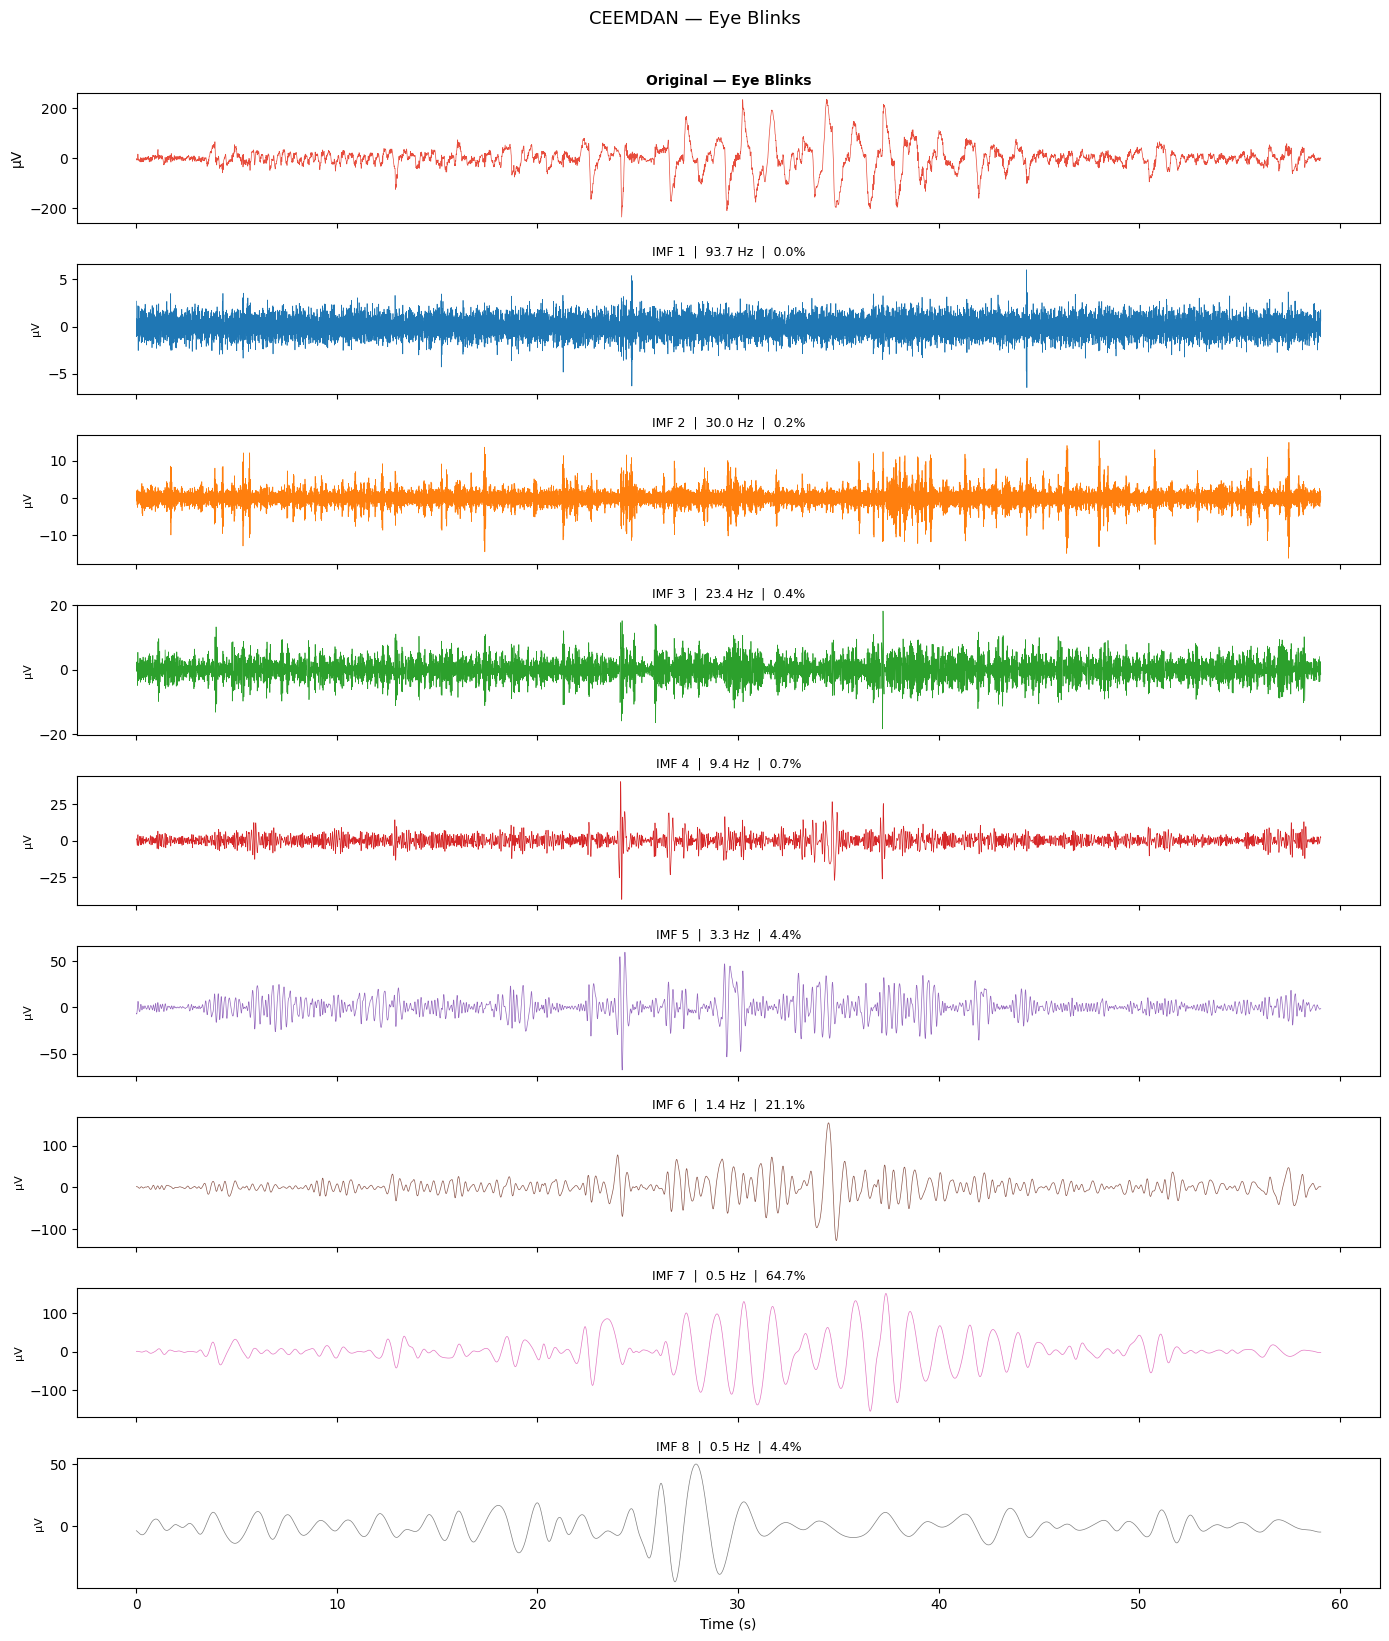

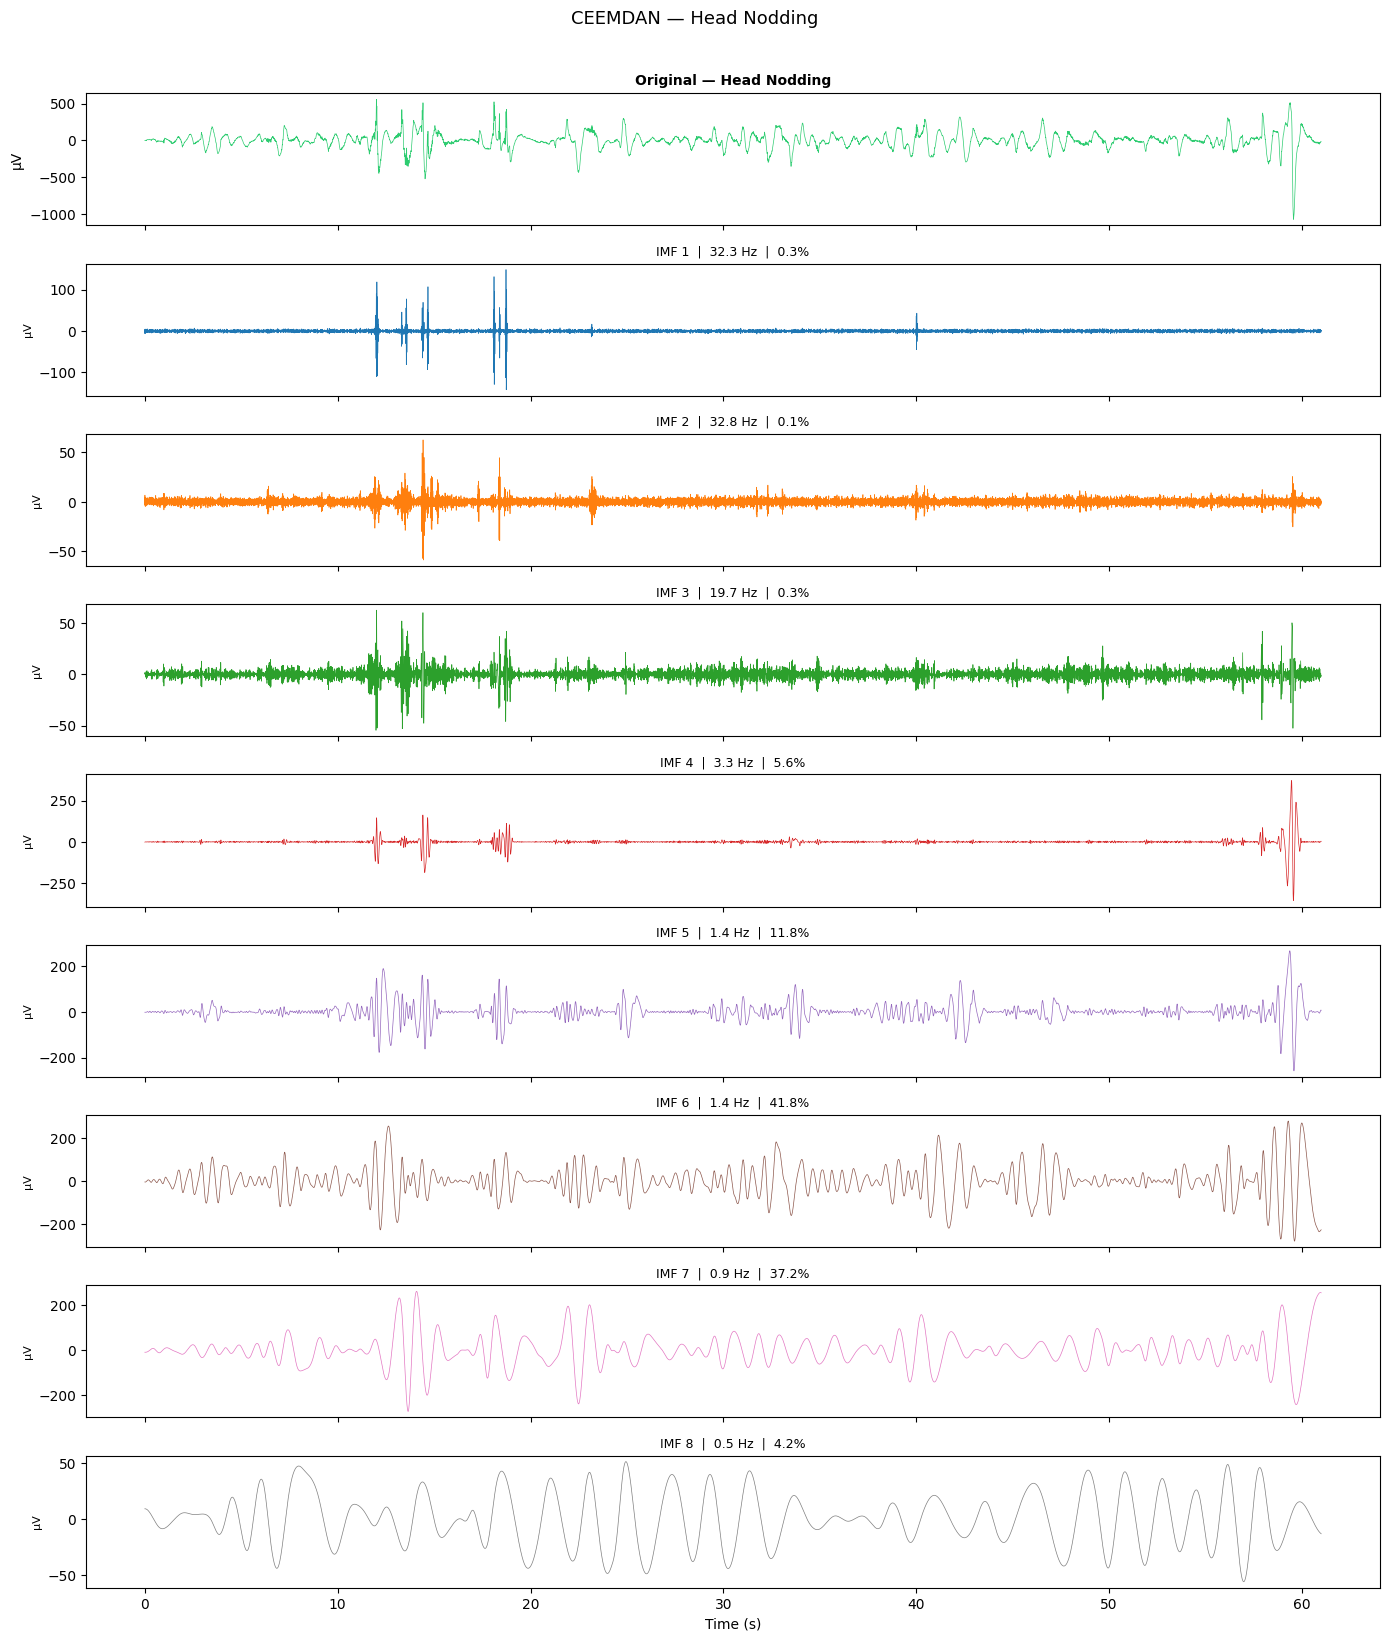

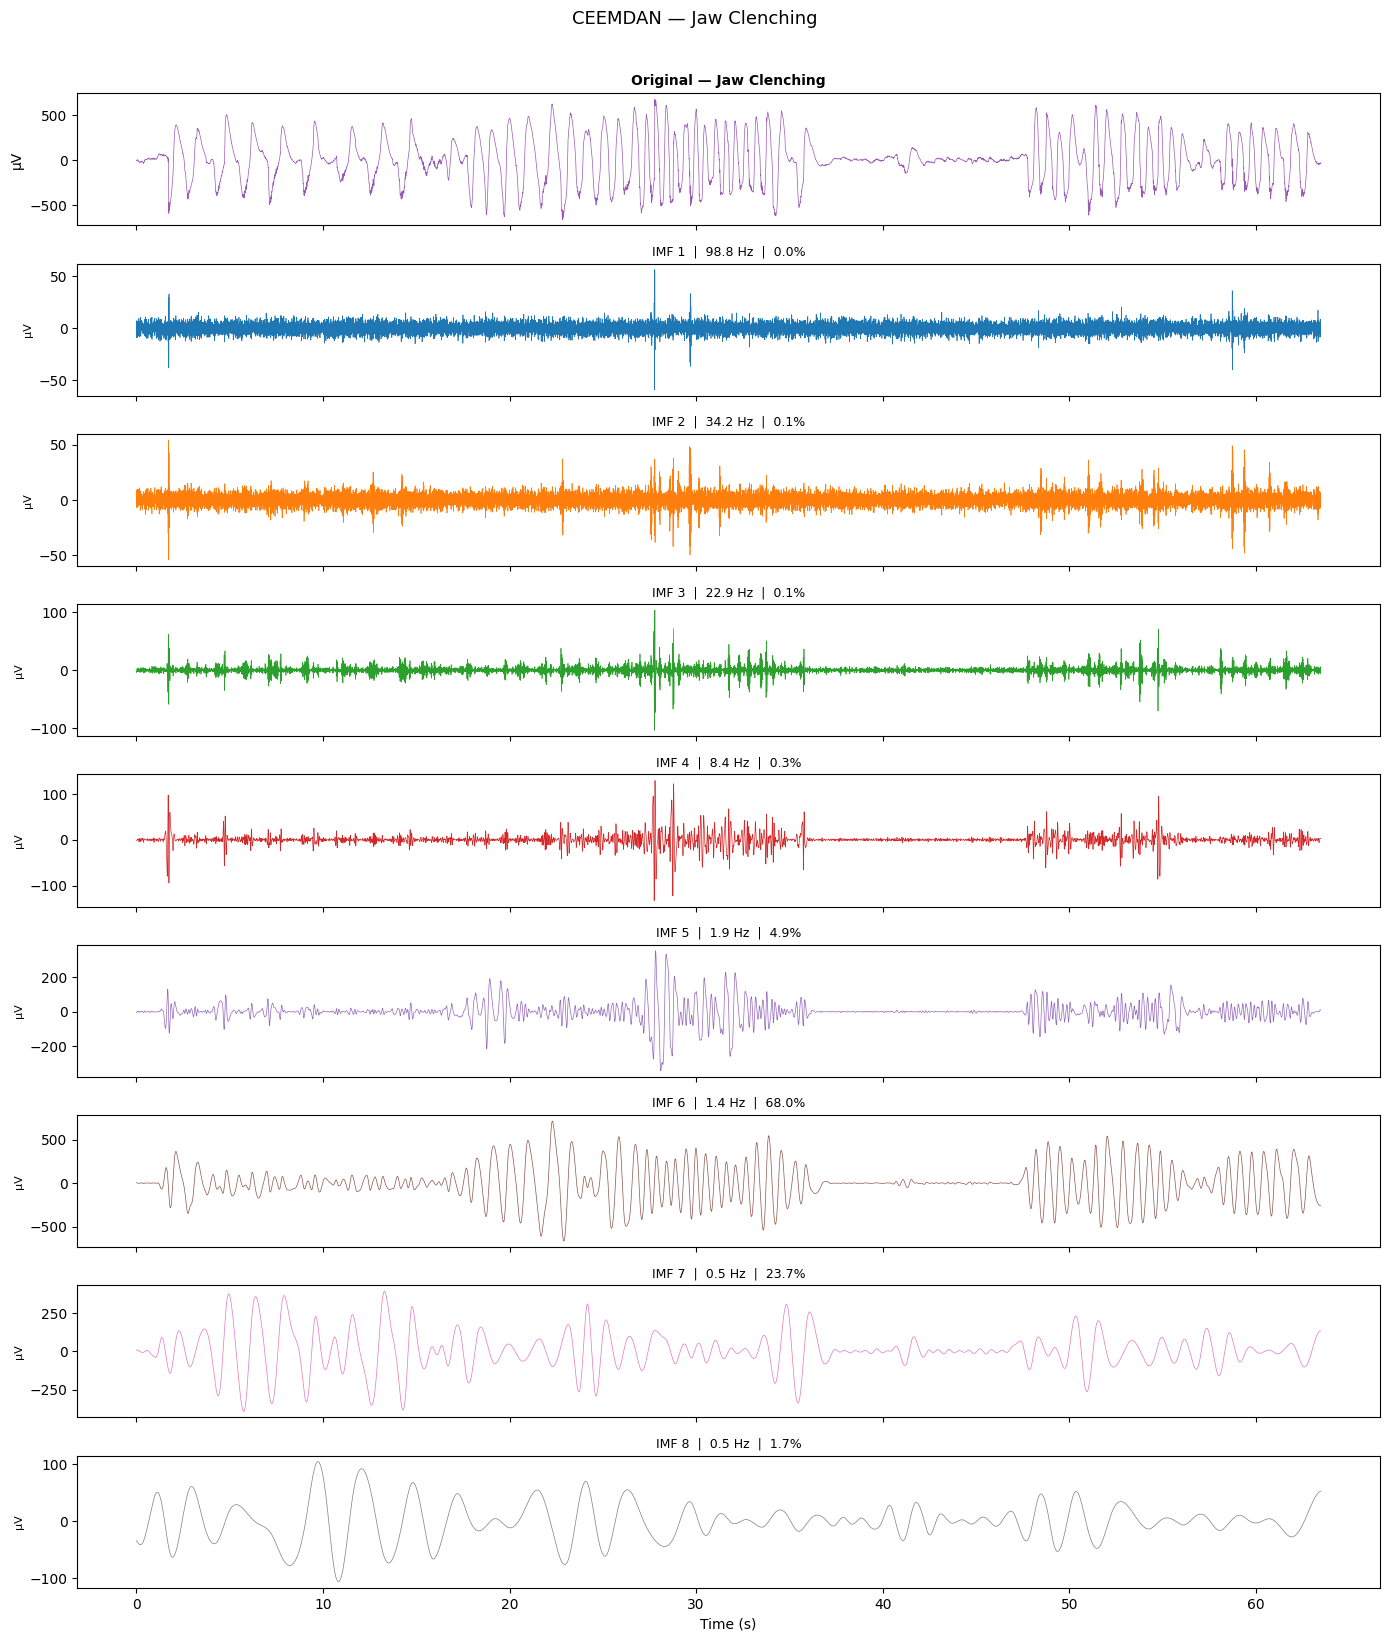

In [7]:
def ceemdan_denoise(sig, t, n_remove=1):
    """CEEMDAN decomposition, reconstruct by removing first n_remove IMFs."""
    ceemdan = CEEMDAN(trials=30, epsilon=0.1)
    ceemdan.noise_seed(42)
    ceemdan.processes = 1  # avoid multiprocessing memory issue
    imfs = ceemdan.ceemdan(sig, t)
    reconstructed = np.sum(imfs[n_remove:], axis=0)
    return imfs, reconstructed

ceemdan_results = {}
ceemdan_imfs_all = {}
for name, (sig, t) in artifacts.items():
    imfs, recon = ceemdan_denoise(sig, t)
    ceemdan_imfs_all[name] = imfs
    ceemdan_results[name] = recon
    print(f'{name}: {imfs.shape[0]} IMFs extracted')

# Plot IMFs for each artifact
for name, (sig, t) in artifacts.items():
    imfs = ceemdan_imfs_all[name]
    n_imfs = min(imfs.shape[0], 8)
    fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 1.8 * (n_imfs + 1)), sharex=True)

    axes[0].plot(t, sig, color=colors[name], linewidth=0.5)
    axes[0].set_title(f'Original — {name}', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('µV')

    for i in range(n_imfs):
        f_psd, psd = welch(imfs[i], fs=fs, nperseg=min(512, len(imfs[i])))
        dom_freq = f_psd[np.argmax(psd)]
        energy_pct = np.sum(imfs[i]**2) / np.sum(sig**2) * 100
        axes[i+1].plot(t, imfs[i], color=plt.cm.tab10(i), linewidth=0.5)
        axes[i+1].set_title(f'IMF {i+1}  |  {dom_freq:.1f} Hz  |  {energy_pct:.1f}%',
                            fontsize=9)
        axes[i+1].set_ylabel('µV', fontsize=8)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'CEEMDAN — {name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 7. VMD — Variational Mode Decomposition
---
VMD is optimization-based — we specify **K=5** modes targeting the main EEG bands. We reconstruct by removing mode 1 (highest center frequency, typically artifact/noise).

Eye Blinks: 5 modes, center freqs = ['-244.9+0.1j', '-190.9+0.0j', '-189.3+0.0j', '-15.3+0.0j', '580.2-0.1j']
Head Nodding: 5 modes, center freqs = ['-933.9+0.2j', '-897.8+0.2j', '97.6-0.0j', '255.3-0.1j', '3500.7-0.8j']
Jaw Clenching: 5 modes, center freqs = ['-11067.8+2.3j', '-906.2+0.2j', '-719.2+0.1j', '645.2-0.1j', '15704.1-3.2j']


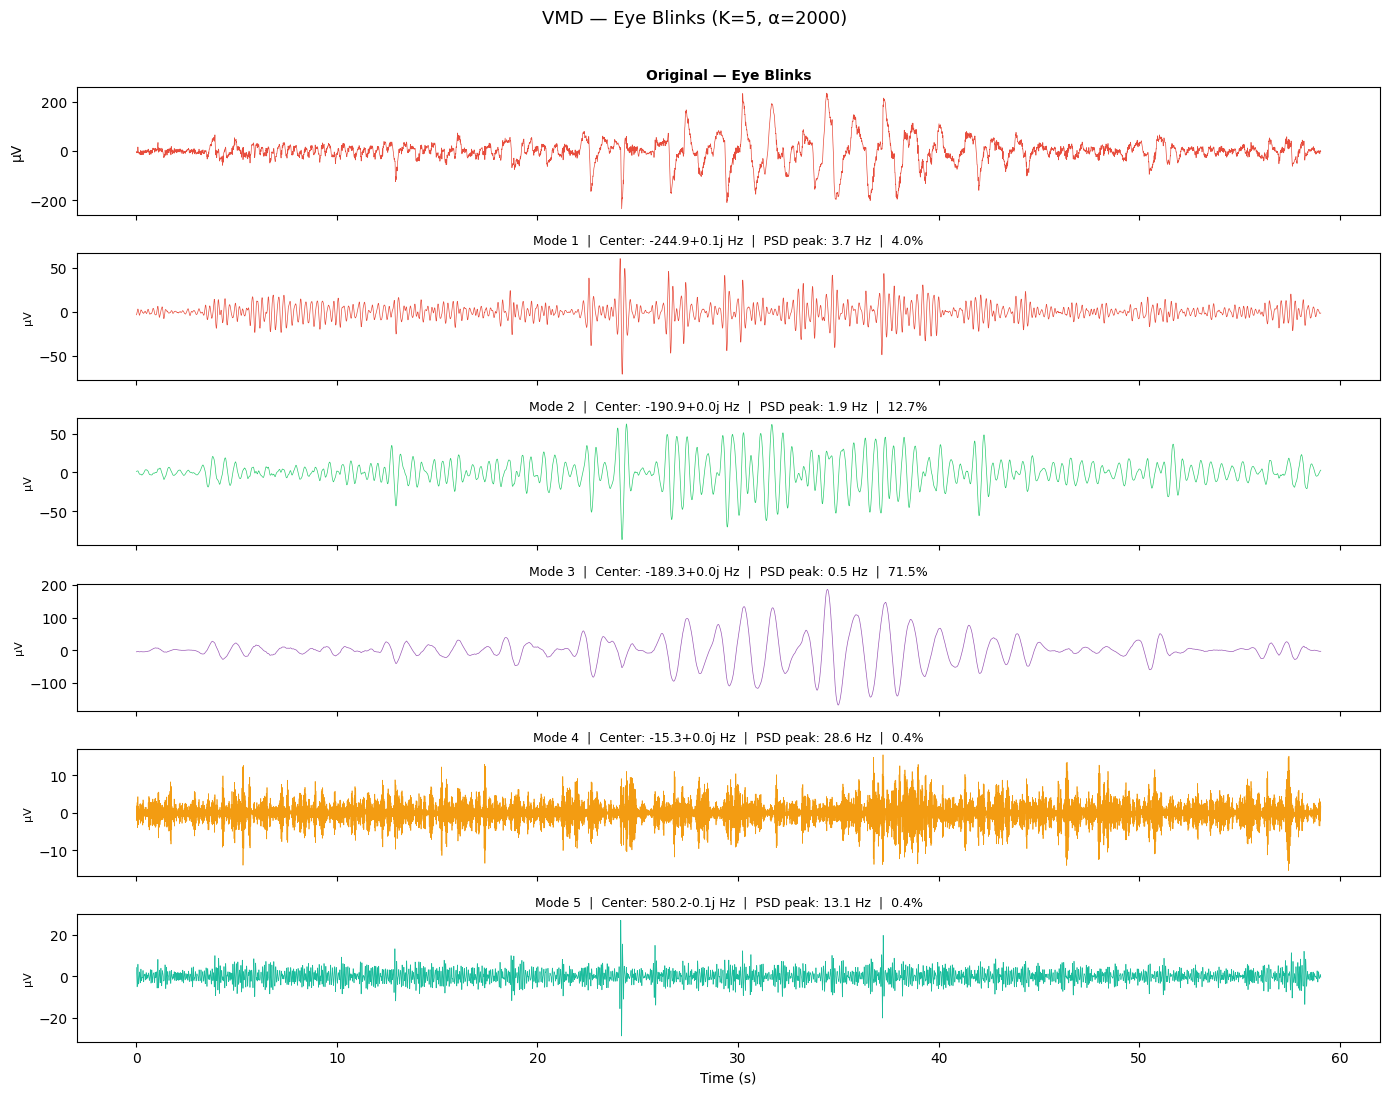

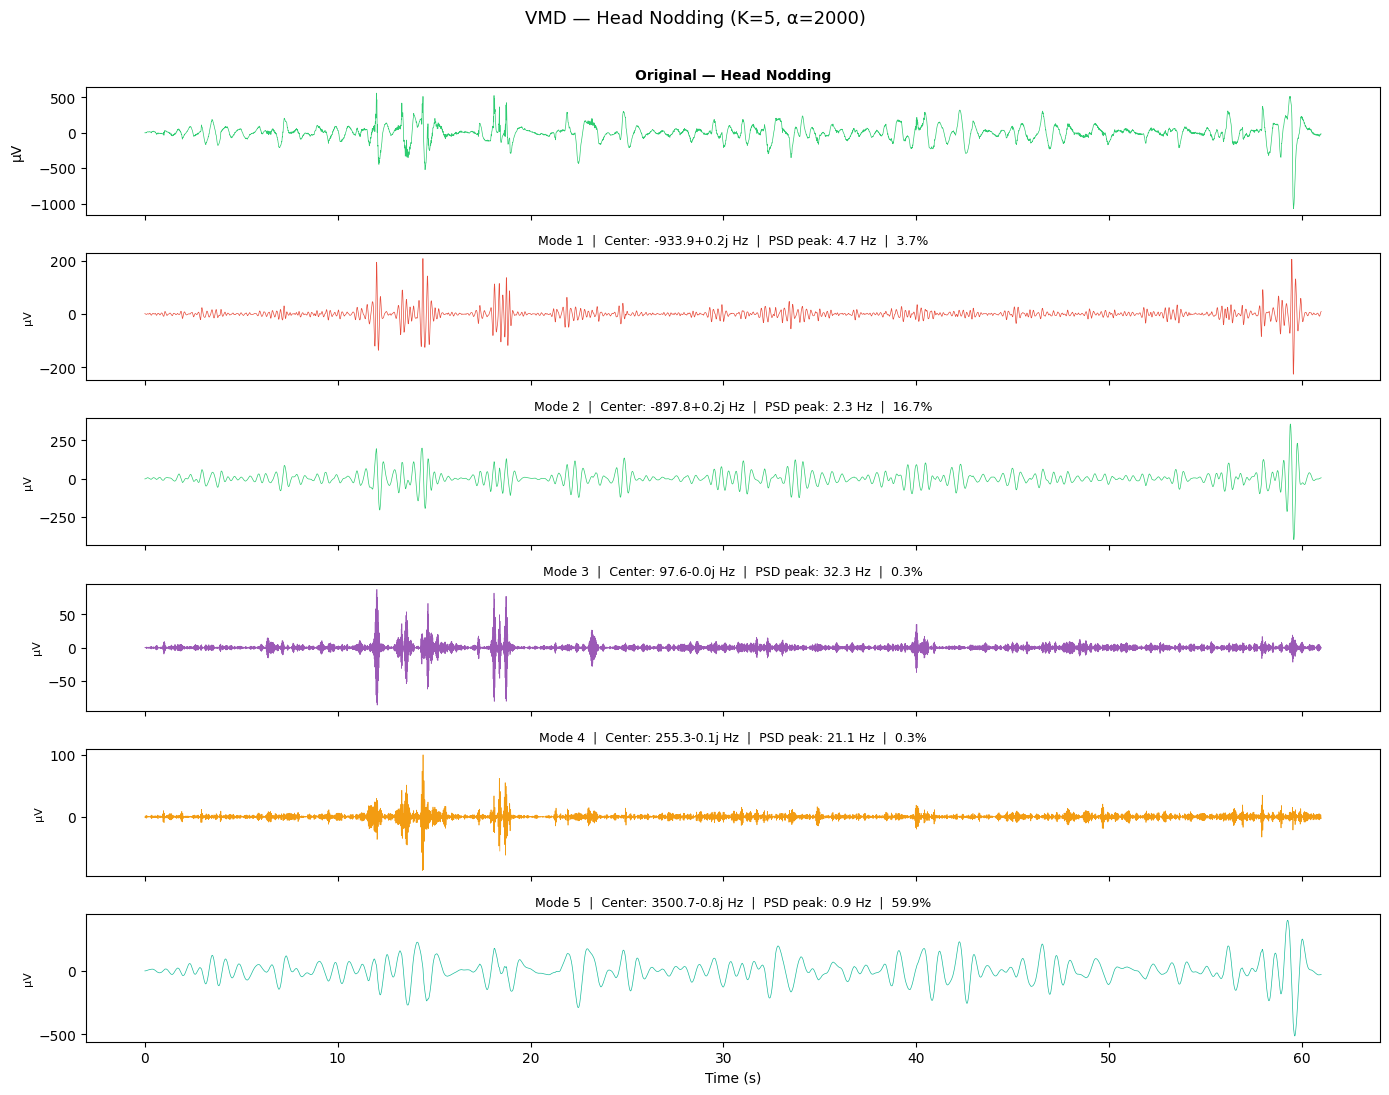

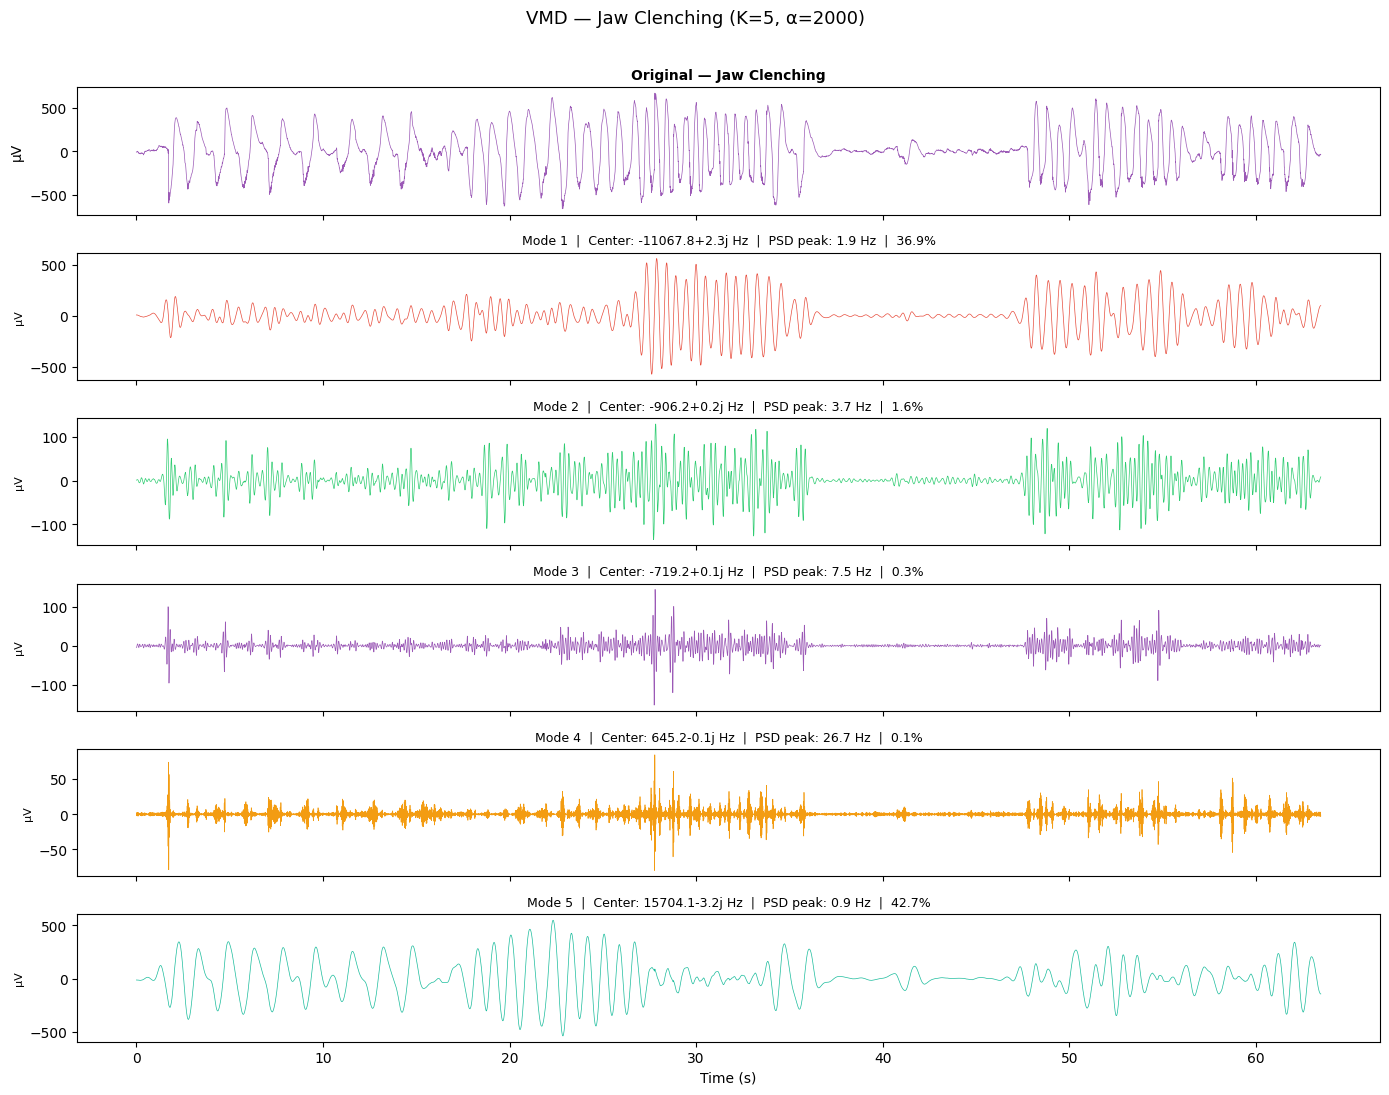

In [8]:
K = 5
alpha = 2000
tau = 0
DC = 0
init = 1
tol = 1e-7

def vmd_denoise(sig, n_remove=1):
    """VMD decomposition, reconstruct by removing first n_remove modes."""
    modes, freqs, _ = VMD(sig, alpha, tau, K, DC, init, tol)
    # Sort modes by center frequency (ascending)
    order = np.argsort(freqs[-1])
    modes = modes[order]
    freqs_sorted = freqs[:, order]
    # Remove the highest-frequency mode(s)
    reconstructed = np.sum(modes[:-n_remove], axis=0)
    return modes, freqs_sorted, reconstructed

vmd_results = {}
vmd_modes_all = {}
vmd_freqs_all = {}
for name, (sig, t) in artifacts.items():
    modes, freqs, recon = vmd_denoise(sig)
    vmd_modes_all[name] = modes
    vmd_freqs_all[name] = freqs
    # Trim to match (VMD can drop 1 sample)
    vmd_results[name] = recon[:len(sig)] if len(recon) >= len(sig) else np.pad(recon, (0, len(sig)-len(recon)), mode='edge')
    print(f'{name}: {K} modes, center freqs = '
          f'{["{:.1f}".format(f*fs) for f in freqs[-1]]}')

# Plot modes for each artifact
for name, (sig, t) in artifacts.items():
    modes = vmd_modes_all[name]
    freqs = vmd_freqs_all[name]
    t_vmd = t[:modes.shape[1]]
    fig, axes = plt.subplots(K + 1, 1, figsize=(14, 1.8 * (K + 1)), sharex=True)

    axes[0].plot(t_vmd, sig[:len(t_vmd)], color=colors[name], linewidth=0.5)
    axes[0].set_title(f'Original — {name}', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('µV')

    colors_vmd = ['#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
    for i in range(K):
        f_psd, psd = welch(modes[i], fs=fs, nperseg=min(512, len(modes[i])))
        dom_freq = f_psd[np.argmax(psd)]
        energy_pct = np.sum(modes[i]**2) / np.sum(sig[:len(t_vmd)]**2) * 100
        axes[i+1].plot(t_vmd, modes[i], color=colors_vmd[i], linewidth=0.5)
        axes[i+1].set_title(
            f'Mode {i+1}  |  Center: {freqs[-1, i]*fs:.1f} Hz  |  '
            f'PSD peak: {dom_freq:.1f} Hz  |  {energy_pct:.1f}%',
            fontsize=9)
        axes[i+1].set_ylabel('µV', fontsize=8)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'VMD — {name} (K={K}, α={alpha})', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 8. Comparison — Original vs All Reconstructed Signals
---
For each artifact type, we overlay the **original** signal with the **reconstructed (denoised)** signal from all five methods. This lets us visually compare how aggressively each method removes the artifact and how much neural signal is preserved.

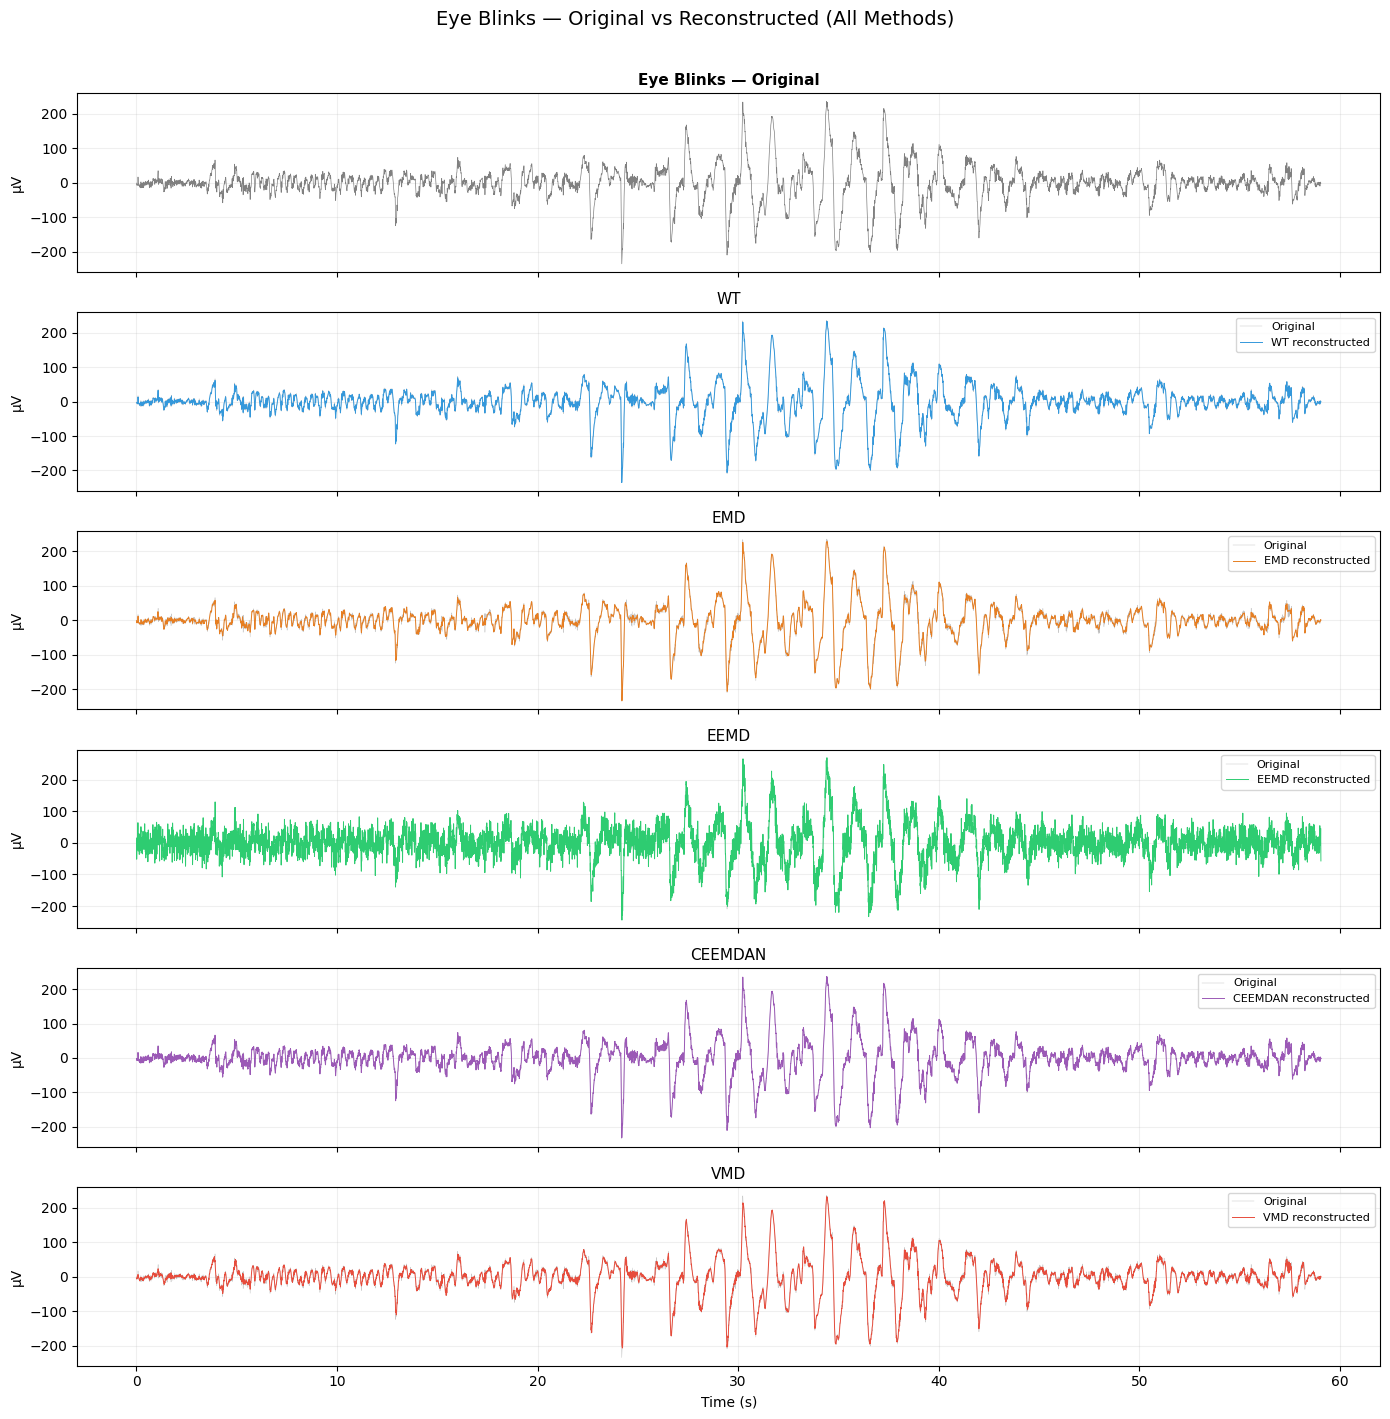

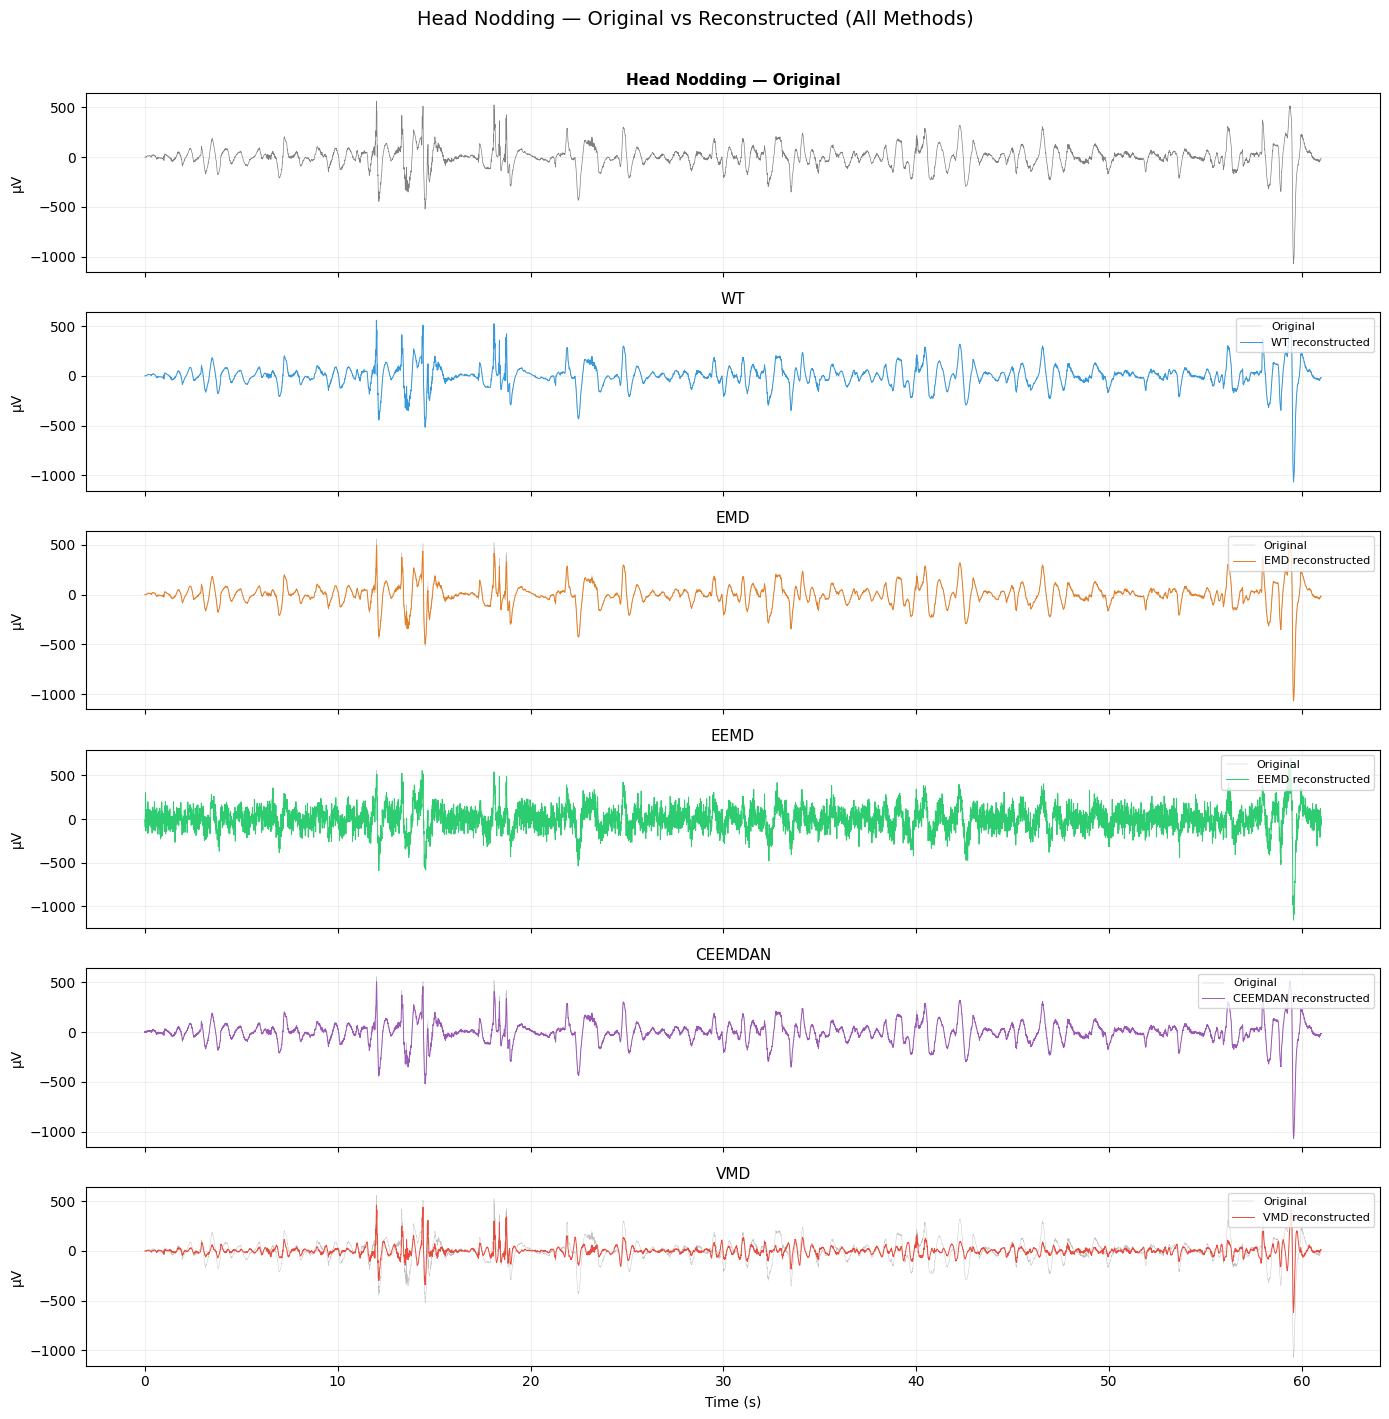

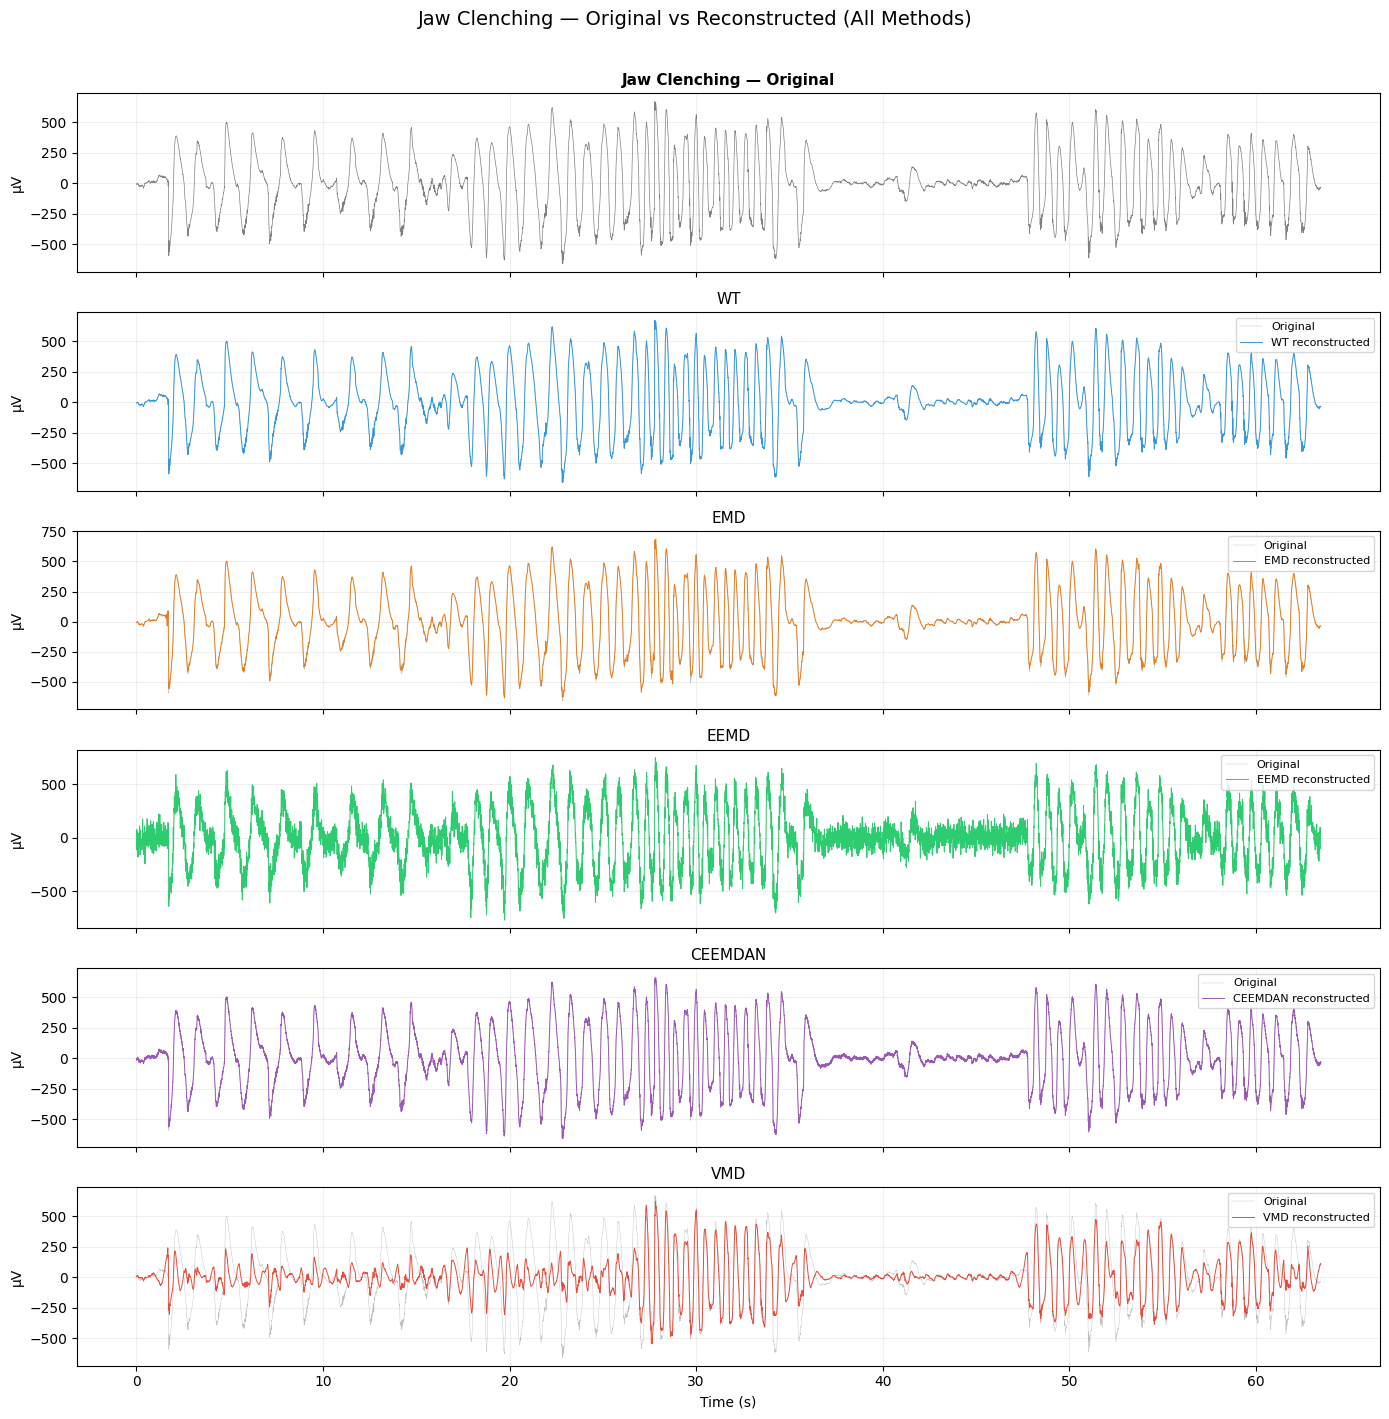

In [9]:
method_colors = {
    'WT':      '#3498db',
    'EMD':     '#e67e22',
    'EEMD':    '#2ecc71',
    'CEEMDAN': '#9b59b6',
    'VMD':     '#e74c3c',
}

for name, (sig, t) in artifacts.items():
    fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

    # Original
    axes[0].plot(t, sig, color='gray', linewidth=0.5)
    axes[0].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('µV')
    axes[0].grid(alpha=0.2)

    # Each method
    all_recons = {
        'WT': wt_results[name],
        'EMD': emd_results[name],
        'EEMD': eemd_results[name],
        'CEEMDAN': ceemdan_results[name],
        'VMD': vmd_results[name],
    }

    for ax, (method, recon) in zip(axes[1:], all_recons.items()):
        # Trim to common length
        n = min(len(sig), len(recon))
        ax.plot(t[:n], sig[:n], color='gray', linewidth=0.3, alpha=0.5, label='Original')
        ax.plot(t[:n], recon[:n], color=method_colors[method], linewidth=0.7,
                label=f'{method} reconstructed')
        ax.set_title(f'{method}', fontsize=11)
        ax.set_ylabel('µV')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'{name} — Original vs Reconstructed (All Methods)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## 9. Quantitative Comparison
---
We compute the **energy removed** and **correlation with original** for each method on each artifact type. Higher energy removal suggests more aggressive artifact suppression; high correlation means the overall signal shape is preserved.

In [11]:
print(f'{"Artifact":<18} {"Method":<10} {"Energy Removed (%)":>20} {"Correlation":>14}')
print('=' * 65)

all_methods = {
    'WT': wt_results,
    'EMD': emd_results,
    'EEMD': eemd_results,
    'CEEMDAN': ceemdan_results,
    'VMD': vmd_results,
}

for name, (sig, t) in artifacts.items():
    for method, results in all_methods.items():
        recon = results[name]
        n = min(len(sig), len(recon))
        orig, rec = sig[:n], recon[:n]
        energy_removed = (1 - np.sum(rec**2) / np.sum(orig**2)) * 100
        corr = np.corrcoef(orig, rec)[0, 1]
        print(f'{name:<18} {method:<10} {energy_removed:>18.1f}% {corr:>14.4f}')
    print('-' * 65)

Artifact           Method       Energy Removed (%)    Correlation
Eye Blinks         WT                        0.9%         0.9993
Eye Blinks         EMD                       0.8%         0.9958
Eye Blinks         EEMD                    -21.8%         0.9079
Eye Blinks         CEEMDAN                   0.1%         0.9998
Eye Blinks         VMD                       2.1%         0.9962
-----------------------------------------------------------------
Head Nodding       WT                        0.4%         0.9998
Head Nodding       EMD                       0.7%         0.9964
Head Nodding       EEMD                    -48.0%         0.8202
Head Nodding       CEEMDAN                   0.4%         0.9983
Head Nodding       VMD                      76.1%         0.6480
-----------------------------------------------------------------
Jaw Clenching      WT                        0.1%         1.0000
Jaw Clenching      EMD                       0.0%         0.9993
Jaw Clenching      EEM

---
### References
- [EEG Artifacts Handling — Brain Products](https://pressrelease.brainproducts.com/eeg-artifacts-handling-in-analyzer/)
- Huang et al., 1998 — The Empirical Mode Decomposition (EMD)
- Wu & Huang, 2009 — Ensemble EMD (EEMD)
- Torres et al., 2011 — CEEMDAN
- Dragomiretskiy & Zosso, 2014 — Variational Mode Decomposition (VMD)